# FIT5202 2026 S2 Assignment 1 : Analysing Parking & Congestion Patterns in Melbourne

## Table of Contents
* [Part 1 : Data Loading and Transformation](#part-1)  
    - [1.1 Data Preparation and Loading](#1.1)  
    - [1.2 Data Cleansing](#1.2)
    - [1.3 Partitition and Spark UI Evidence](#1.3)    
* [Part 2 : Working with DataFrames](#2-dataframes)  
    - [2.1 Create the Time Attributes](#2.1)  
    - [2.2 Join with the Area and Street Lookup Tables](#2.2)  
    - [2.3 Compare Parking Activity and Violation Rates](#2.3)  
    - [2.4 Identify High-use and Long-stay Parking Bays](#2.4)  
    - [2.5 Combine Parking Activity with Traffic Volume](#2.5)  
    - [2.6 Exploratory Analysis](#2.6)  
* [Part 3 : Query Optimisation](#part-3)  
    - [3.1 DataFrame API and Spark SQL](#3.1)  
    - [3.2 Baseline Plan and Spark UI Analysis](#3.2)  
    - [3.3 Evaluate One Optimisation](#3.3)  

Note: Feel free to add Code/Markdown cells as you need.

# Part 1 : Data Loading and Transformation (10%) <a class="anchor" name="part-1"></a>
In this section, you need to create data frames from the given datasets, perform partitioning and use various operations to answer the queries.  

## 1.1 Data Preparation and Loading <a class="anchor" name="1.1"></a>
1. Configure the Spark session to run locally using four cores;
1. Assign an appropriate application name to the Spark session;
1. Set the session timezone explicitly to 'Australia/Melbourne';
1. Define and apply an explicit StructType schema when loading each CSV and JSON dataset. 
1. Print the schema and row count for each DataFrame;
1. Display the first five rows of each DataFrame to verify successful data loading.

In [1]:
from pyspark import SparkConf
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import *

student_auth_code="xxuu0177"

conf=SparkConf().setMaster("local[4]").setAppName("FIT5202 A1 - Melbourne Parking and Congestion")\
    .set("spark.sql.session.timeZone","Australia/Melbourne")\
    .set("spark.driver.memory","3g")
spark=SparkSession.builder.config(conf=conf).getOrCreate()
spark.conf.set("spark.sql.ansi.enabled","false")  # invalid values -> null instead of raising an error
sc=spark.sparkContext
sc.setLogLevel("ERROR")
print(sc.master, "|", sc.appName, "|", spark.conf.get("spark.sql.session.timeZone"))

local[4] | FIT5202 A1 - Melbourne Parking and Congestion | Australia/Melbourne


In [2]:
# times and ids read as string first, converted in 1.2
parking_schema=StructType([
    StructField("deviceid",StringType(),True),
    StructField("arrivaltime",StringType(),True),
    StructField("departuretime",StringType(),True),
    StructField("streetmarker",StringType(),True),
    StructField("signplateid",StringType(),True),
    StructField("sign",StringType(),True),
    StructField("streetid",IntegerType(),True),
    StructField("betweenstreet1id",StringType(),True),
    StructField("betweenstreet2id",StringType(),True),  # contains values like "1,043"
    StructField("sideofstreet",IntegerType(),True),
    StructField("sidename",StringType(),True),
    StructField("bayid",StringType(),True),
    StructField("inviolation",StringType(),True),
    StructField("vehiclepresent",StringType(),True),
    StructField("areaid",IntegerType(),True)])
df_parking=spark.read.csv("sensordata.csv",header=True,schema=parking_schema)
df_parking.printSchema()
print("parking rows:",df_parking.count())
df_parking.show(5,truncate=False)

root
 |-- deviceid: string (nullable = true)
 |-- arrivaltime: string (nullable = true)
 |-- departuretime: string (nullable = true)
 |-- streetmarker: string (nullable = true)
 |-- signplateid: string (nullable = true)
 |-- sign: string (nullable = true)
 |-- streetid: integer (nullable = true)
 |-- betweenstreet1id: string (nullable = true)
 |-- betweenstreet2id: string (nullable = true)
 |-- sideofstreet: integer (nullable = true)
 |-- sidename: string (nullable = true)
 |-- bayid: string (nullable = true)
 |-- inviolation: string (nullable = true)
 |-- vehiclepresent: string (nullable = true)
 |-- areaid: integer (nullable = true)



parking rows: 72912582


+--------+----------------------+----------------------+------------+-----------+----+--------+----------------+----------------+------------+--------+-----+-----------+--------------+------+
|deviceid|arrivaltime           |departuretime         |streetmarker|signplateid|sign|streetid|betweenstreet1id|betweenstreet2id|sideofstreet|sidename|bayid|inviolation|vehiclepresent|areaid|
+--------+----------------------+----------------------+------------+-----------+----+--------+----------------+----------------+------------+--------+-----+-----------+--------------+------+
|17193   |10/23/2018 06:49:29 AM|10/23/2018 06:54:24 AM|13029S      |NULL       |NULL|528     |1285            |79              |4           |South   |6015 |false      |false         |35    |
|17193   |02/07/2018 07:30:00 PM|02/07/2018 07:56:23 PM|13029S      |NULL       |NULL|528     |1285            |79              |4           |South   |6015 |false      |false         |35    |
|17195   |11/22/2018 07:22:38 AM|11/22/2

In [3]:
# json is wrapped like {"area":[...]} -> read multiline then explode
area_schema=StructType([StructField("area",ArrayType(StructType([
    StructField("areaid",IntegerType(),True),
    StructField("areaname",StringType(),True)])),True)])
df_area=spark.read.json("area.json",schema=area_schema,multiLine=True)\
    .select(F.explode("area").alias("a")).select("a.areaid","a.areaname")
df_area.printSchema()
print("area rows:",df_area.count())
df_area.show(5)

street_schema=StructType([StructField("street",ArrayType(StructType([
    StructField("streetid",IntegerType(),True),
    StructField("streetname",StringType(),True)])),True)])
df_street=spark.read.json("street.json",schema=street_schema,multiLine=True)\
    .select(F.explode("street").alias("s")).select("s.streetid","s.streetname")
df_street.printSchema()
print("street rows:",df_street.count())
df_street.show(5)

root
 |-- areaid: integer (nullable = true)
 |-- areaname: string (nullable = true)



area rows: 38


+------+---------+
|areaid| areaname|
+------+---------+
|     1|   County|
|     2|Tavistock|
|     3|    Banks|
|     4|     Mint|
|     5|   Domain|
+------+---------+
only showing top 5 rows
root
 |-- streetid: integer (nullable = true)
 |-- streetname: string (nullable = true)



street rows: 126
+--------+----------------+
|streetid|      streetname|
+--------+----------------+
|       5|A'BECKETT STREET|
|       8|   ACLAND STREET|
|      11|    AGNES STREET|
|      13|   AIRLIE STREET|
|      16|   ALBERT STREET|
+--------+----------------+
only showing top 5 rows


In [4]:
traffic_schema=StructType([
    StructField("d_year",IntegerType(),True),
    StructField("d_month",IntegerType(),True),
    StructField("d_day",IntegerType(),True),
    StructField("d_hour",IntegerType(),True),
    StructField("d_minute",IntegerType(),True),
    StructField("areaid",IntegerType(),True),
    StructField("traffic_count",IntegerType(),True)])
df_traffic=spark.read.csv("traffic_count.csv",header=True,schema=traffic_schema)
df_traffic.printSchema()
print("traffic rows:",df_traffic.count())
df_traffic.show(5)

root
 |-- d_year: integer (nullable = true)
 |-- d_month: integer (nullable = true)
 |-- d_day: integer (nullable = true)
 |-- d_hour: integer (nullable = true)
 |-- d_minute: integer (nullable = true)
 |-- areaid: integer (nullable = true)
 |-- traffic_count: integer (nullable = true)



traffic rows: 10956114
+------+-------+-----+------+--------+------+-------------+
|d_year|d_month|d_day|d_hour|d_minute|areaid|traffic_count|
+------+-------+-----+------+--------+------+-------------+
|  2018|      1|    1|     0|       1|    16|           65|
|  2018|      1|    1|     0|       1|    16|           75|
|  2018|      1|    1|     0|       1|    16|           56|
|  2018|      1|    1|     0|       1|    16|           97|
|  2018|      1|    1|     0|       1|    16|          148|
+------+-------+-----+------+--------+------+-------------+
only showing top 5 rows


### 1.2 Data Cleansing and Validation <a class="anchor" name="1.2"></a>
The following tasks must be completed to ensure data quality and consistency (feel free to add code block as you see fit):
1) Identify the missing-value representations within the dataset and convert them to null. Briefly state which values were treated as missing.

In [5]:
# 1.2.1 look for nulls / blanks / missing markers
str_cols=[f.name for f in df_parking.schema.fields if isinstance(f.dataType,StringType)]
num_cols=[f.name for f in df_parking.schema.fields if f.name not in str_cols]
miss=["","NA","N/A","NULL","NONE","NAN","-","?"]
chk=[]
for c in str_cols:
    chk.append(F.sum(F.when(F.col(c).isNull(),1).otherwise(0)).alias(c+"_null"))
    chk.append(F.sum(F.when(F.upper(F.trim(F.col(c))).isin(miss),1).otherwise(0)).alias(c+"_marker"))
for c in num_cols:
    chk.append(F.sum(F.when(F.col(c).isNull(),1).otherwise(0)).alias(c+"_null"))
r=df_parking.agg(*chk).first()
rows=[(c,"string",r[c+"_null"],r[c+"_marker"]) for c in str_cols]+[(c,"int",r[c+"_null"],0) for c in num_cols]
spark.createDataFrame(rows,["column","type","null_count","blank_or_marker_count"]).show(truncate=False)

+----------------+------+----------+---------------------+
|column          |type  |null_count|blank_or_marker_count|
+----------------+------+----------+---------------------+
|deviceid        |string|0         |0                    |
|arrivaltime     |string|0         |0                    |
|departuretime   |string|0         |0                    |
|streetmarker    |string|0         |0                    |
|signplateid     |string|25195820  |0                    |
|sign            |string|25195820  |0                    |
|betweenstreet1id|string|0         |0                    |
|betweenstreet2id|string|57538     |0                    |
|sidename        |string|0         |0                    |
|bayid           |string|0         |0                    |
|inviolation     |string|0         |0                    |
|vehiclepresent  |string|0         |0                    |
|streetid        |int   |0         |0                    |
|sideofstreet    |int   |0         |0                   

In [6]:
# blanks and markers -> null, df_parking stays unchanged
clean=df_parking
for c in str_cols:
    clean=clean.withColumn(c,F.when(F.upper(F.trim(F.col(c))).isin(miss),None).otherwise(F.trim(F.col(c))))

# lookup tables: areaid 7 has an empty name
df_area_c=df_area.withColumn("areaname",F.when(F.trim("areaname")=="",None).otherwise(F.trim("areaname")))
df_street_c=df_street.withColumn("streetname",F.when(F.trim("streetname")=="",None).otherwise(F.trim("streetname")))
# traffic: d_minute is the 10-min block number inside the hour (0-5)
df_traffic_c=df_traffic.na.drop().filter("traffic_count>=0 and d_minute between 0 and 5 and d_hour between 0 and 23")
print("area rows with missing name:",df_area_c.filter("areaname is null").count())
print("traffic rows before/after cleaning:",df_traffic.count(),"/",df_traffic_c.count())

area rows with missing name: 1


traffic rows before/after cleaning: 10956114 / 10956114


**Missing values (1.2.1)**

Each string column was examined for null entries, blank or whitespace-only strings, and the standard placeholders used to denote missing data (NA, N/A, NULL, NONE, NaN, -, ?). Because Spark's CSV reader already converts empty fields to null on read, missing values are reflected only in `null_count`: `signplateid` and `sign` are empty in 25,195,820 rows (approximately 34.6% of the file), and `betweenstreet2id` is empty in 57,538 rows. None of the textual placeholders occur in the data, and the columns required by later tasks (arrival and departure times, device id, bay id, violation flag, area id and street id) contain no missing values.

Blank strings, whitespace-only strings and the placeholder markers listed above are converted to null across every string column of the cleaned copy `clean`, while `df_parking` retains the originally loaded values. The lookup tables are treated under the same rule: area 7 in `area.json` has an empty name that is likewise set to null. The traffic table required no such treatment, as its row count remains 10,956,114 both before and after cleaning.

2) Parse the 'ArrivalTime' and 'DepartureTime' columns and convert them to timestamp format. 

In [7]:
# raw looks like "10/23/2018 06:49:29 AM" -> 12 hour clock
# rename raw cols first, spark names are case-insensitive
fmt="MM/dd/yyyy hh:mm:ss a"
clean=clean.withColumnRenamed("arrivaltime","arr_raw").withColumnRenamed("departuretime","dep_raw")\
    .withColumn("ArrivalTime",F.to_timestamp("arr_raw",fmt))\
    .withColumn("DepartureTime",F.to_timestamp("dep_raw",fmt))
clean.select("arr_raw","ArrivalTime","dep_raw","DepartureTime").show(5,truncate=False)

+----------------------+-------------------+----------------------+-------------------+
|arr_raw               |ArrivalTime        |dep_raw               |DepartureTime      |
+----------------------+-------------------+----------------------+-------------------+
|10/23/2018 06:49:29 AM|2018-10-23 06:49:29|10/23/2018 06:54:24 AM|2018-10-23 06:54:24|
|02/07/2018 07:30:00 PM|2018-02-07 19:30:00|02/07/2018 07:56:23 PM|2018-02-07 19:56:23|
|11/22/2018 07:22:38 AM|2018-11-22 07:22:38|11/22/2018 07:28:22 AM|2018-11-22 07:28:22|
|09/18/2018 09:24:56 PM|2018-09-18 21:24:56|09/18/2018 09:27:44 PM|2018-09-18 21:27:44|
|01/04/2018 12:00:00 AM|2018-01-04 00:00:00|01/04/2018 03:45:46 AM|2018-01-04 03:45:46|
+----------------------+-------------------+----------------------+-------------------+
only showing top 5 rows


3) Convert the “DeviceId” to an appropriate numeric type. 

In [8]:
# DeviceId -> int, plus the other id/flag columns
clean=clean.withColumnRenamed("deviceid","dev_raw")\
    .withColumn("DeviceId",F.col("dev_raw").cast(IntegerType()))\
    .withColumn("BayId",F.regexp_replace("bayid",",","").cast(IntegerType()))\
    .withColumn("betweenstreet1id",F.regexp_replace("betweenstreet1id",",","").cast(IntegerType()))\
    .withColumn("betweenstreet2id",F.regexp_replace("betweenstreet2id",",","").cast(IntegerType()))\
    .withColumn("InViolation",F.col("inviolation").cast(BooleanType()))\
    .withColumn("VehiclePresent",F.col("vehiclepresent").cast(BooleanType()))
clean.select("dev_raw","DeviceId","BayId","InViolation","VehiclePresent").show(5)

+-------+--------+-----+-----------+--------------+
|dev_raw|DeviceId|BayId|InViolation|VehiclePresent|
+-------+--------+-----+-----------+--------------+
|  17193|   17193| 6015|      false|         false|
|  17193|   17193| 6015|      false|         false|
|  17195|   17195| 6016|      false|          true|
|  17195|   17195| 6016|      false|         false|
|  17195|   17195| 6016|      false|          true|
+-------+--------+-----+-----------+--------------+
only showing top 5 rows


4) Calculate a new “DurationMinutes” column using the arrival and departure timestamp. Store the result as a DoubleType value and rounded to two decimal places.

In [9]:
clean=clean.withColumn("DurationMinutes",
    F.round((F.col("DepartureTime").cast("long")-F.col("ArrivalTime").cast("long"))/60,2).cast(DoubleType()))
clean.select("ArrivalTime","DepartureTime","DurationMinutes").show(5)

+-------------------+-------------------+---------------+
|        ArrivalTime|      DepartureTime|DurationMinutes|
+-------------------+-------------------+---------------+
|2018-10-23 06:49:29|2018-10-23 06:54:24|           4.92|
|2018-02-07 19:30:00|2018-02-07 19:56:23|          26.38|
|2018-11-22 07:22:38|2018-11-22 07:28:22|           5.73|
|2018-09-18 21:24:56|2018-09-18 21:27:44|            2.8|
|2018-01-04 00:00:00|2018-01-04 03:45:46|         225.77|
+-------------------+-------------------+---------------+
only showing top 5 rows


5) Identify and report records where the departure time is earlier than the arrival time. Briefly discuss any pattern observed and state how these records will be handled in duration-based queries.

In [10]:
# departure earlier than arrival, cached since used a few times
neg=clean.filter(F.col("DepartureTime")<F.col("ArrivalTime")).cache()
print("records with DepartureTime < ArrivalTime:",neg.count())
neg.select("DeviceId","arr_raw","dep_raw","DurationMinutes").show(10,truncate=False)
neg.describe("DurationMinutes").show()
# look for a pattern by date and arrival hour
neg.groupBy(F.to_date("ArrivalTime").alias("arr_date")).count().orderBy(F.desc("count")).show(10)
neg.groupBy(F.hour("ArrivalTime").alias("arr_hour")).count().orderBy(F.desc("count")).show(5)
# DST starts 2018-10-07 / 2019-10-06 (2:00->3:00), check those days
dst=neg.filter(F.to_date("ArrivalTime").isin("2018-10-07","2019-10-06")).count()
big=neg.filter("DurationMinutes < -1440").count()
print("on DST start days:",dst,"| negative by more than one day:",big,"| others:",neg.count()-dst-big)

records with DepartureTime < ArrivalTime: 408
+--------+----------------------+----------------------+---------------+
|DeviceId|arr_raw               |dep_raw               |DurationMinutes|
+--------+----------------------+----------------------+---------------+
|19020   |02/23/2018 09:10:58 PM|02/23/2018 11:59:25 AM|-551.55        |
|17788   |10/07/2018 02:59:21 AM|10/07/2018 03:00:55 AM|-58.43         |
|17789   |10/07/2018 02:59:12 AM|10/07/2018 03:01:28 AM|-57.73         |
|27554   |10/06/2019 02:59:59 AM|10/06/2019 03:50:59 AM|-9.0           |
|17244   |10/07/2018 02:03:14 AM|10/07/2018 03:03:02 AM|-0.2           |
|17261   |10/07/2018 02:18:18 AM|10/07/2018 03:12:35 AM|-5.72          |
|17322   |10/07/2018 02:55:19 AM|10/07/2018 03:12:51 AM|-42.47         |
|17361   |10/07/2018 02:47:19 AM|10/07/2018 03:37:33 AM|-9.77          |
|17377   |10/07/2018 02:56:45 AM|10/07/2018 03:06:59 AM|-49.77         |
|17590   |04/21/2018 01:55:00 PM|04/21/2018 01:45:42 PM|-9.3           |
+----

+-------+------------------+
|summary|   DurationMinutes|
+-------+------------------+
|  count|               408|
|   mean|-74094.86875000002|
| stddev|120830.58338648126|
|    min|        -493288.88|
|    max|             -0.12|
+-------+------------------+



+----------+-----+
|  arr_date|count|
+----------+-----+
|2019-10-06|   51|
|2018-03-19|   37|
|2018-10-07|   26|
|2018-12-04|   21|
|2019-05-08|   13|
|2018-07-06|   12|
|2019-07-26|    8|
|2019-04-14|    8|
|2019-07-28|    7|
|2018-04-21|    7|
+----------+-----+
only showing top 10 rows


+--------+-----+
|arr_hour|count|
+--------+-----+
|       3|   87|
|       7|   41|
|      22|   34|
|      20|   34|
|      18|   33|
+--------+-----+
only showing top 5 rows


on DST start days: 77 | negative by more than one day: 148 | others: 183


**Departure earlier than arrival (1.2.5)**

Of the 72.9 million records, 408 (0.0006%) fail this check, and they fall into three groups.

- **77 records occur on 2018-10-07 and 2019-10-06**, the dates on which daylight saving begins in Melbourne. Because local clocks advance directly from 02:00 to 03:00, an arrival recorded at 02:59 has no corresponding instant in the session timezone; Spark shifts such an arrival forward by one hour to 03:59, and a departure recorded a few minutes later therefore precedes it. This explains why arrival hour 3 is the most frequent hour among the reversed records.
- **148 records are negative by more than one day**, reaching -493,288 minutes (approximately 343 days). A discrepancy of this size indicates an incorrect departure date, most plausibly the result of a sensor or data-entry error.
- **The remaining 183 records** show small negative gaps spread across many dates. Several are consistent with an AM/PM transcription error, for example an arrival at 02/23/2018 09:10:58 PM paired with a departure at 11:59:25 AM.

These records are retained, since the arrival is valid and the parking session took place. Their `DurationMinutes` value is treated as invalid, so duration-based queries include only rows with `DurationMinutes >= 0`. No repair is attempted, as the data provide no reliable basis for reconstructing the true departure time.

6) Explain how records with missing or invalid departure information will be handled in subsequent duration-based queries.

**Missing or invalid departures (1.2.6)**

A duration is computed only when `DepartureTime` is present, parses successfully, and is not earlier than `ArrivalTime`. Records failing any of these conditions are excluded from the duration measures used in 2.4, where `ValidDurationSessions` and `AverageDurationMinutes` are calculated only from rows satisfying `DurationMinutes IS NOT NULL AND DurationMinutes >= 0`. These records are not removed from the cleaned DataFrame, however, because a valid arrival still represents a parking session and still contributes to turnover and to the peak and off-peak counts. Since the validation summary in 1.2.8 reports no missing or unparseable departures, the only records excluded here are the 408 reversed records identified in 1.2.5.

7) Display and print the schema for DeviceId, ArrivalTime, DepartureTime and DurationMinutes.

In [11]:
clean.select("DeviceId","ArrivalTime","DepartureTime","DurationMinutes").printSchema()
clean.select("DeviceId","ArrivalTime","DepartureTime","DurationMinutes").show(5,truncate=False)

root
 |-- DeviceId: integer (nullable = true)
 |-- ArrivalTime: timestamp (nullable = true)
 |-- DepartureTime: timestamp (nullable = true)
 |-- DurationMinutes: double (nullable = true)

+--------+-------------------+-------------------+---------------+
|DeviceId|ArrivalTime        |DepartureTime      |DurationMinutes|
+--------+-------------------+-------------------+---------------+
|17193   |2018-10-23 06:49:29|2018-10-23 06:54:24|4.92           |
|17193   |2018-02-07 19:30:00|2018-02-07 19:56:23|26.38          |
|17195   |2018-11-22 07:22:38|2018-11-22 07:28:22|5.73           |
|17195   |2018-09-18 21:24:56|2018-09-18 21:27:44|2.8            |
|17195   |2018-01-04 00:00:00|2018-01-04 03:45:46|225.77         |
+--------+-------------------+-------------------+---------------+
only showing top 5 rows


8) Display a validation summary table containing the count for each of the following:
- total parking records;
- ArrivalTime parsing failures;
- DepartureTime parsing failures;
- DeviceId conversion failures;
- records with missing DepartureTime;
- records where DepartureTime is earlier than ArrivalTime.

In [12]:
# all counts in one pass over the data
v=clean.agg(F.count("*").alias("total"),
    F.sum(F.when(F.col("arr_raw").isNotNull()&F.col("ArrivalTime").isNull(),1).otherwise(0)).alias("arr_fail"),
    F.sum(F.when(F.col("dep_raw").isNotNull()&F.col("DepartureTime").isNull(),1).otherwise(0)).alias("dep_fail"),
    F.sum(F.when(F.col("dev_raw").isNotNull()&F.col("DeviceId").isNull(),1).otherwise(0)).alias("dev_fail"),
    F.sum(F.when(F.col("dep_raw").isNull(),1).otherwise(0)).alias("dep_missing"),
    F.sum(F.when(F.col("DepartureTime")<F.col("ArrivalTime"),1).otherwise(0)).alias("dep_before_arr")).first()
summary=spark.createDataFrame([
    ("total parking records",v["total"]),
    ("ArrivalTime parsing failures",v["arr_fail"]),
    ("DepartureTime parsing failures",v["dep_fail"]),
    ("DeviceId conversion failures",v["dev_fail"]),
    ("records with missing DepartureTime",v["dep_missing"]),
    ("DepartureTime earlier than ArrivalTime",v["dep_before_arr"])],["validation_check","count"])
summary.show(truncate=False)

+--------------------------------------+--------+
|validation_check                      |count   |
+--------------------------------------+--------+
|total parking records                 |72912582|
|ArrivalTime parsing failures          |0       |
|DepartureTime parsing failures        |0       |
|DeviceId conversion failures          |0       |
|records with missing DepartureTime    |0       |
|DepartureTime earlier than ArrivalTime|408     |
+--------------------------------------+--------+



### 1.3 Partition and Spark UI Evidence <a class="anchor" name="1.3"></a>
1.3.1) Display the total number of partitions within the cleaned parking DataFrame.

In [13]:
print("number of partitions in cleaned parking df:",clean.rdd.getNumPartitions())

number of partitions in cleaned parking df: 69


1.3.2) Print the number of records in each partition. Immediately before running this action, set the following Spark Job description: sc.setJobDescription(f"A1-P1-{student_auth_code}")

In [14]:
# spark_partition_id tags each row with its input partition
sc.setJobDescription(f"A1-P1-{student_auth_code}")
pc=clean.groupBy(F.spark_partition_id().alias("pid")).count().orderBy("pid").collect()
sc.setJobDescription(None)
for x in pc:
    print(f"partition {x['pid']}: {x['count']} records")
cnts=[x["count"] for x in pc]
print("min:",min(cnts),"max:",max(cnts),"avg:",round(sum(cnts)/len(cnts)))

partition 0: 1093088 records
partition 1: 1045808 records
partition 2: 1043416 records
partition 3: 1054580 records
partition 4: 1095648 records
partition 5: 1064542 records
partition 6: 1073063 records
partition 7: 1085498 records
partition 8: 1069231 records
partition 9: 1043017 records
partition 10: 1049272 records
partition 11: 1059697 records
partition 12: 1051963 records
partition 13: 1052721 records
partition 14: 1047821 records
partition 15: 1069659 records
partition 16: 1051222 records
partition 17: 1069043 records
partition 18: 1072379 records
partition 19: 1042332 records
partition 20: 1053826 records
partition 21: 1072522 records
partition 22: 1053381 records
partition 23: 1059832 records
partition 24: 1058740 records
partition 25: 1061174 records
partition 26: 1056094 records
partition 27: 1060892 records
partition 28: 1059880 records
partition 29: 1069792 records
partition 30: 1068101 records
partition 31: 1066977 records
partition 32: 1060594 records
partition 33: 106173

1.3.3) Include a set of screenshots from the Spark UI tab that clearly show:  
- the job tab with the specified job description;
- the relevant stage and its number of tasks
- the task input size, input records or task-duration distribution.

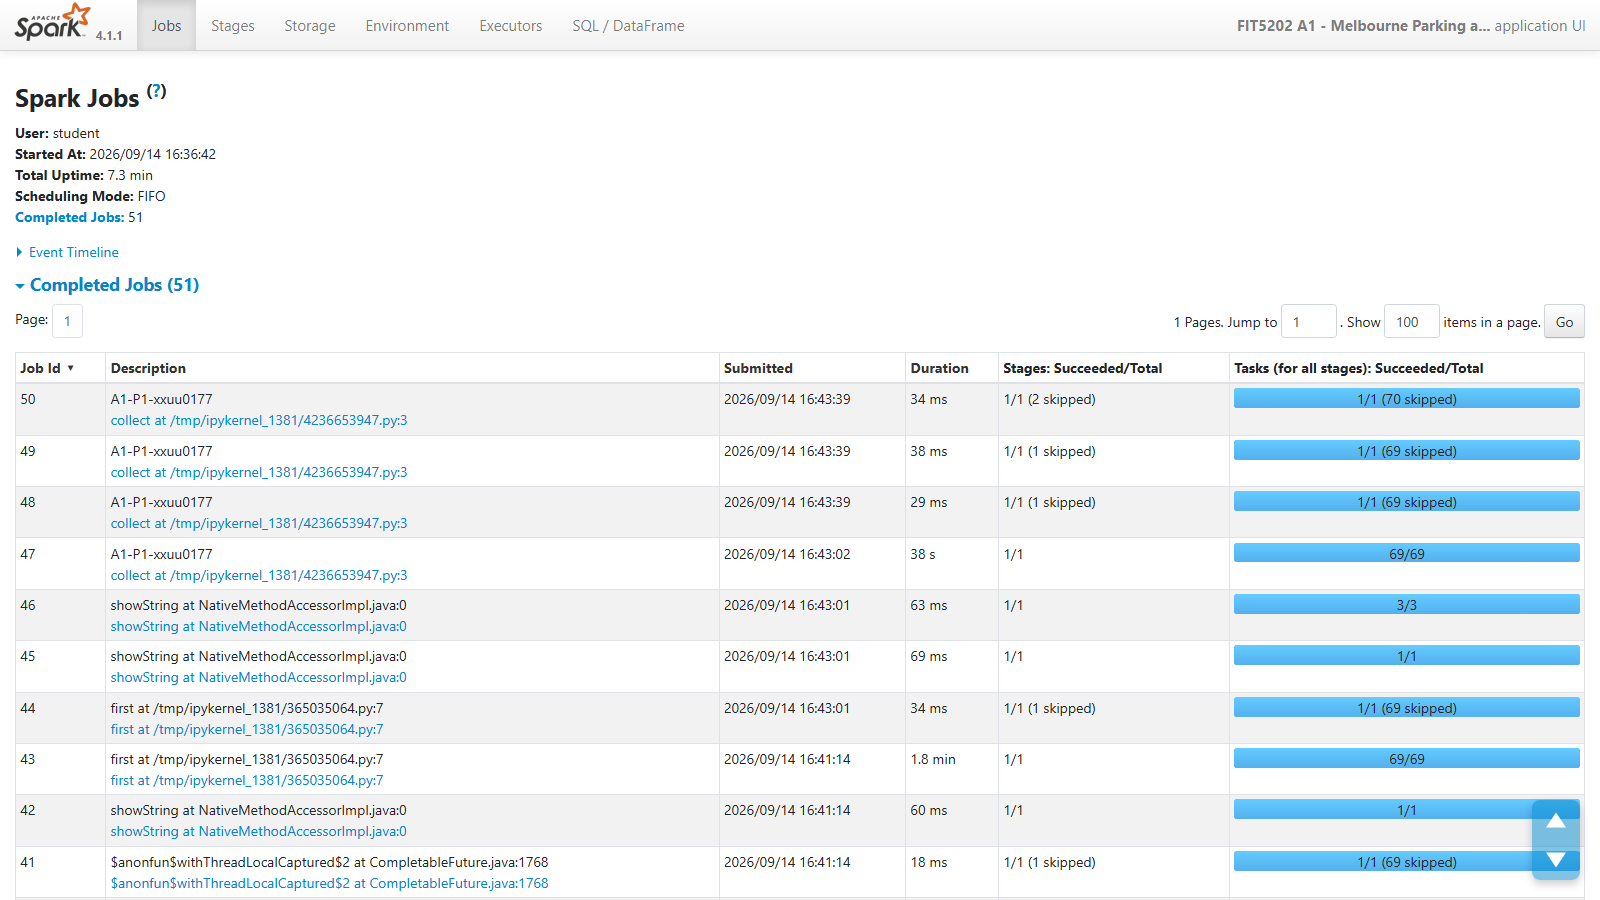

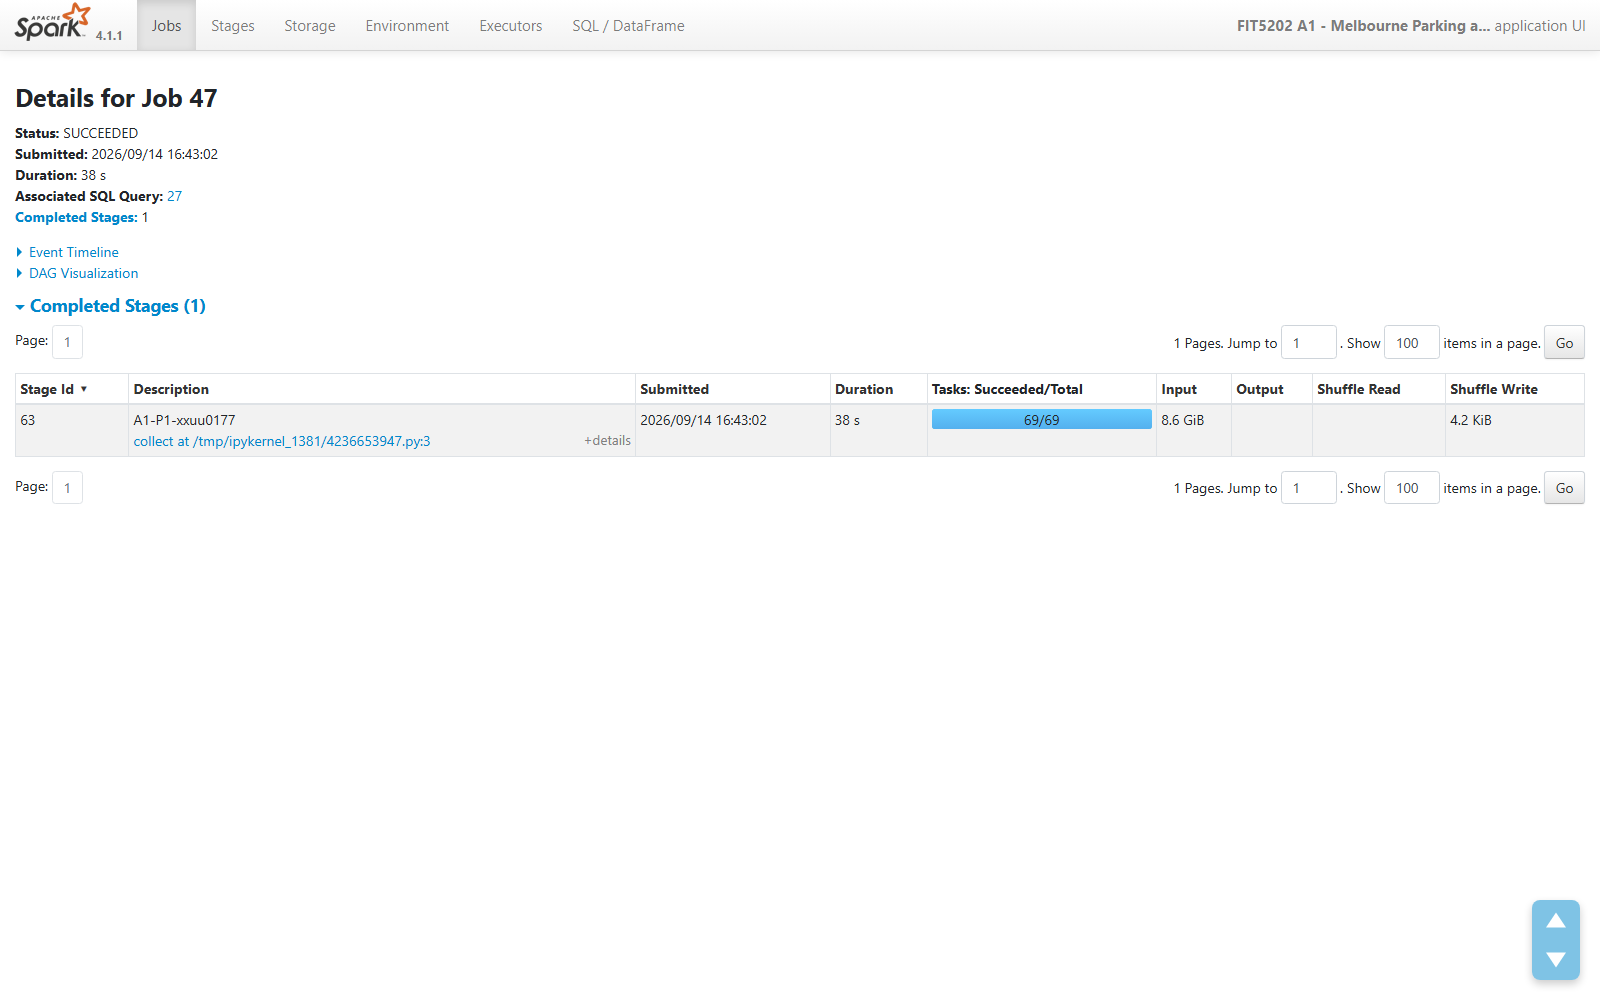

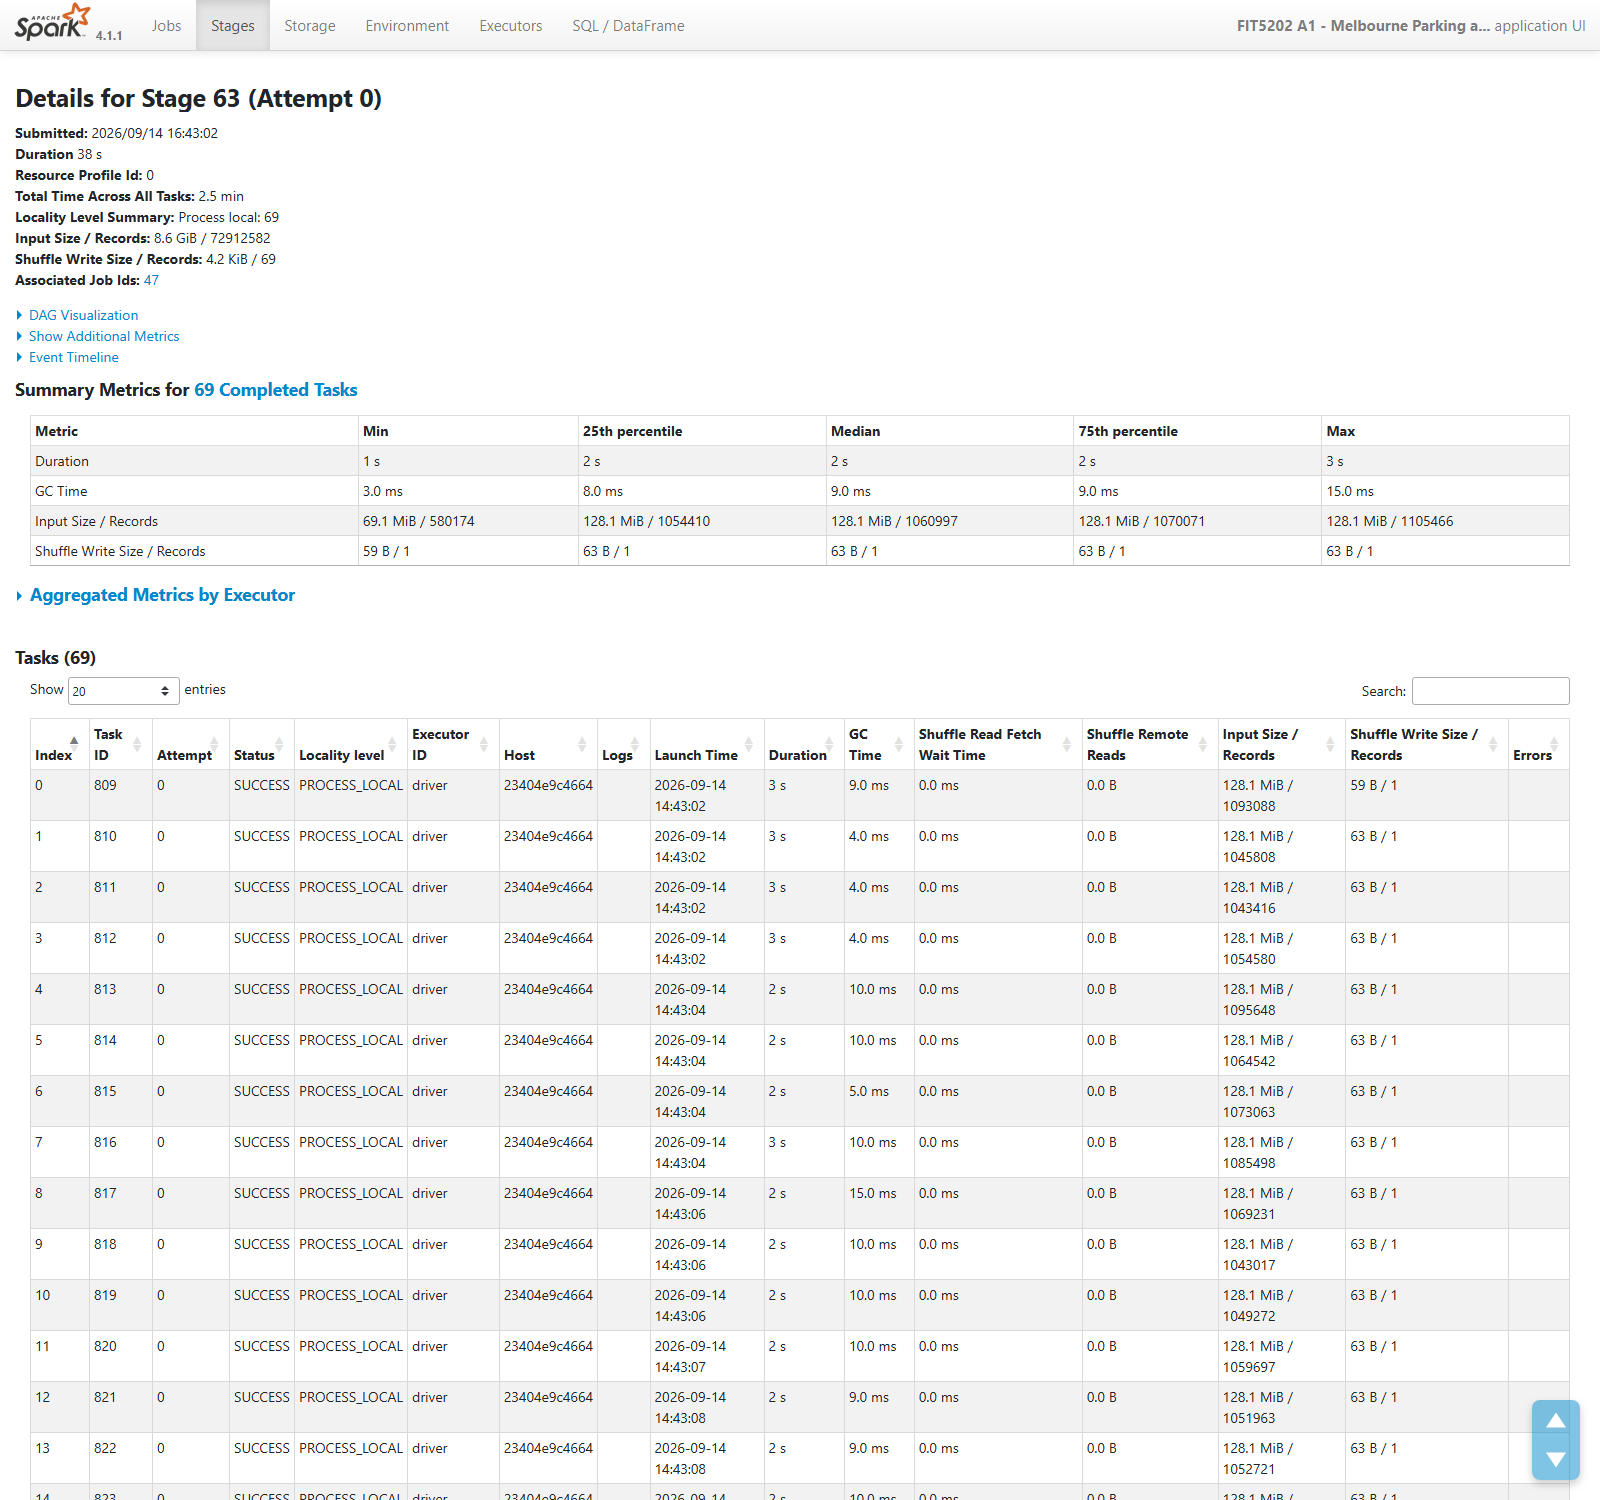

In [15]:
from IPython.display import Image, display
# Spark UI screenshots for the job above
for f in ["p1_jobs.png","p1_job_stages.png","p1_stage_tasks.png"]:
    display(Image(filename="screenshots/"+f))

1.3.4) Analyse the figures in the screenshot and briefly comment on whether the workload appears evenly distributed across the partitions. If not, why?

**Workload distribution (1.3.4)**

Stage 63 of job `A1-P1-xxuu0177` scans the file using **69 tasks**, one per input partition, reading 8.6 GiB / 72,912,582 records in total. The summary metrics report an input size of **128.1 MiB** at the 25th percentile, the median, the 75th percentile and the maximum, and every task completes within 1 s to 3 s. This indicates an evenly distributed workload: no task behaves as a straggler, and the data skew discussed in Week 4, in which one processor receives a disproportionately large share of work, does not occur here.

The smallest task (69.1 MiB / 580,174 records) corresponds to the final partition, which holds the remainder of the file after 68 full splits and therefore finishes earlier. The full partitions still vary slightly in row count (1,030,413 to 1,105,466), because Spark divides the file by byte size rather than by row count, and record lengths are not uniform.

This division differs from the tuple partitioning methods covered in Week 2 (round-robin, hash and range partitioning). No partitioning attribute is involved at this stage, since the file is split purely by size; the resulting balance therefore depends on the physical layout of the file rather than on the distribution of attribute values.

1.3.5) Provide a concise explanation detailing how Spark determines the initial number and approximate size of input partitions when reading from a CSV file.

**Initial input partitions for CSV files (1.3.5)**

For file-based sources, Spark first derives a maximum split size:

`maxSplitBytes = min(maxPartitionBytes, max(openCostInBytes, bytesPerCore))`, where `bytesPerCore = (total bytes + number of files x openCostInBytes) / default parallelism`

The default values are `spark.sql.files.maxPartitionBytes` = 128 MB and `spark.sql.files.openCostInBytes` = 4 MB. For a file of 9,199,285,361 bytes and a default parallelism of 4, `bytesPerCore` is approximately 2.3 GB, so the split size is capped at 128 MB (134,217,728 bytes). Because an uncompressed CSV file is splittable, this produces ⌈9,199,285,361 / 134,217,728⌉ = **69 partitions**: 68 partitions of 128 MiB and one final partition of approximately 69.1 MiB, matching the 69 tasks observed in the screenshot. Each split boundary is aligned to a line break so that no record is divided, which accounts for the small differences in row count between partitions.

The same rule packs multiple small files into a single partition up to the size limit. Compression changes this outcome, since a gzip-compressed CSV is not splittable and would be read as a single partition, leaving three of the four cores idle.

## Part 2. Working with DataFrames (35%) <a class="anchor" name="2-dataframes"></a>
In this section, you need to use DataFrame functions to answer the queries.

2.1 Create the time attributes <a class="anchor" name="2.1"></a>  
2.1.1) From ArrivalTime, create columns for: year; month; day of week;  arrival hour and arrival minute;.

In [16]:
df2=clean.withColumn("year",F.year("ArrivalTime"))\
    .withColumn("month",F.month("ArrivalTime"))\
    .withColumn("dayofweek",F.dayofweek("ArrivalTime"))\
    .withColumn("arr_hour",F.hour("ArrivalTime"))\
    .withColumn("arr_min",F.minute("ArrivalTime"))

2.1.2) With day of week and hour and minutes, create a new column named isPeak and set the value to True or False (i.e. True = Peak Hour, False = Non-peak hour).  
- Peak hours are:
- Weekdays 7:00 - 9:00 am (excluding 9:00 am) and 4:00 - 6:30 pm ( excluding 6:30 pm).
- Non-peak hours are times outside these periods.
- Represent day of week using Spark’s convention: 1 = Sunday, 2 = Monday……

In [17]:
# dayofweek 1=Sun..7=Sat, so weekdays are 2-6
# minutes of day: 7:00-9:00 = [420,540), 16:00-18:30 = [960,1110)
mins=F.col("arr_hour")*60+F.col("arr_min")
weekday=F.col("dayofweek").between(2,6)
df2=df2.withColumn("isPeak",weekday&(((mins>=420)&(mins<540))|((mins>=960)&(mins<1110))))

2.1.3) Display five rows containing ArrivalTime, year, month, day of week, arrival hour, arrival minute and isPeak, and print the relevant schema.

In [18]:
df2.select("ArrivalTime","year","month","dayofweek","arr_hour","arr_min","isPeak").show(5,truncate=False)
df2.select("ArrivalTime","year","month","dayofweek","arr_hour","arr_min","isPeak").printSchema()

+-------------------+----+-----+---------+--------+-------+------+
|ArrivalTime        |year|month|dayofweek|arr_hour|arr_min|isPeak|
+-------------------+----+-----+---------+--------+-------+------+
|2018-10-23 06:49:29|2018|10   |3        |6       |49     |false |
|2018-02-07 19:30:00|2018|2    |4        |19      |30     |false |
|2018-11-22 07:22:38|2018|11   |5        |7       |22     |true  |
|2018-09-18 21:24:56|2018|9    |3        |21      |24     |false |
|2018-01-04 00:00:00|2018|1    |5        |0       |0      |false |
+-------------------+----+-----+---------+--------+-------+------+
only showing top 5 rows
root
 |-- ArrivalTime: timestamp (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- arr_hour: integer (nullable = true)
 |-- arr_min: integer (nullable = true)
 |-- isPeak: boolean (nullable = true)



2.2 Join the cleaned parking sensor data with both lookup tables to add the area and street names. (Note:The area and street lookup table is provided in JSON format). <a class="anchor" name="2.2"></a>  
Select an appropriate join type;
- Report the number of parking records that do not match an area look up row and the number that do not match a street lookup row. 
- Identify a suitable join strategy for these joins and justify your choice.
- Display the first five joined records with the following columns: DeviceId, AreaId, AreaName, StreetId, and StreetName.

In [19]:
# left join keeps every parking record so unmatched ones can be counted
# lookups are tiny -> broadcast instead of shuffling 72M rows
area_lk=df_area_c.withColumn("area_hit",F.lit(1))
street_lk=df_street_c.withColumn("street_hit",F.lit(1))
j=df2.join(F.broadcast(area_lk),"areaid","left").join(F.broadcast(street_lk),"streetid","left")

um=j.agg(F.sum(F.when(F.col("area_hit").isNull(),1).otherwise(0)).alias("no_area"),
         F.sum(F.when(F.col("areaid").isNull(),1).otherwise(0)).alias("null_area"),
         F.sum(F.when(F.col("street_hit").isNull(),1).otherwise(0)).alias("no_street"),
         F.sum(F.when(F.col("streetid").isNull(),1).otherwise(0)).alias("null_street")).first()
print("records with no matching area row:",um["no_area"],"(areaid is null in",um["null_area"],"of them)")
print("records with no matching street row:",um["no_street"],"(streetid is null in",um["null_street"],"of them)")

j.select("DeviceId",F.col("areaid").alias("AreaId"),F.col("areaname").alias("AreaName"),
         F.col("streetid").alias("StreetId"),F.col("streetname").alias("StreetName")).show(5,truncate=False)
j.select("DeviceId","areaname","streetname").explain()

records with no matching area row: 0 (areaid is null in 0 of them)
records with no matching street row: 0 (streetid is null in 0 of them)


+--------+------+---------+--------+--------------+
|DeviceId|AreaId|AreaName |StreetId|StreetName    |
+--------+------+---------+--------+--------------+
|17193   |35    |Docklands|528     |COLLINS STREET|
|17193   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
|17195   |35    |Docklands|528     |COLLINS STREET|
+--------+------+---------+--------+--------------+
only showing top 5 rows
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [DeviceId#442, areaname#384, streetname#385]
   +- BroadcastHashJoin [streetid#6], [streetid#123], LeftOuter, BuildRight, false
      :- Project [streetid#6, DeviceId#442, areaname#384]
      :  +- BroadcastHashJoin [areaid#14], [areaid#100], LeftOuter, BuildRight, false
      :     :- Project [streetid#6, areaid#14, CASE WHEN upper(trim(deviceid#0, None)) IN (,NA,N/A,NULL,NONE,NAN,-,?) THEN null ELSE cast(trim(deviceid#0, None) as int) 

**Join type and strategy (2.2)**

**Join type: left outer join**, with the parking data as the left input. A left join retains every parking record, so records without a lookup match remain in the result and can be counted, whereas an inner join would discard them without indication. A constant flag column is added to each lookup table so that a genuine non-match can be distinguished from area 7, whose name is null after cleaning.

**Result:** all parking records match an area and a street; no record has a null `areaid` or `streetid`, so every record receives both names.

**Strategy: broadcast join, the Divide and Broadcast method described in Week 3.** The lookup tables are very small (38 areas and 126 streets, a few KB each) relative to 72.9 million parking rows, so Spark distributes a copy of each lookup table to every partition and performs the join locally. The physical plan confirms this strategy, containing `BroadcastHashJoin ... LeftOuter, BuildRight`, with a `BroadcastExchange` on the lookup side and no exchange on the parking side.

Disjoint partitioning would instead hash both inputs on the join key and redistribute them, requiring all 72.9 million parking rows to be moved in order to meet a table of only a few kilobytes. The Week 3 cost model favours Divide and Broadcast whenever one input is small enough to replicate, and both lookup tables satisfy this condition well within the threshold.

### 2.3 Compare Parking Activity and Violation Rates <a class="anchor" name="2.3"></a>
The council would like to compare parking activity and violation patterns during peak and off-peak periods.  
For each parking area:
- PeakDailyAverage: the average number of valid peak-hour sessions per active weekday.
- PeakViolationRate: percentage of valid peak-hour sessions marked as InViolation.
- OffPeakDailyAverage: the average number of valid off-peak sessions per active day.
- OffPeakViolationRate: the percentage of valid off-peak sessions marked as InViolation.
- TotalValidSessions: total peak and off-peak sessions.
1) Display the ten areas with the highest TotalValidSessions, ordered by TotalValidSessions descending. If counts are equal, order by AreaId ascending. 
1) Briefly compare the peak and off-peak results and discuss whether higher parking activity appears to correspond with higher violation rates among these areas.
Note:  
- Violation rate = (sessions where Inviolation is true) / (sessions with a valid Inviolation value in the same period) * 100%.
- A valid session must have a non-null AreaID, and a successfully parsed ArrivalTime. 
- Calculate each violation rate using sessions with a valid InViolation value in the corresponding period.
- A missing DepartureTime does not invalidate a session because duration is not used in this task.
- An active day is a date on which the area has at least one valid parking session.

In [20]:
# valid session = areaid not null + parsed ArrivalTime
base23=df2.filter(F.col("areaid").isNotNull()&F.col("ArrivalTime").isNotNull())
pk=F.col("isPeak")
# per area per day first, then per area. active day = date with >=1 session
daily=base23.groupBy("areaid",F.to_date("ArrivalTime").alias("d"),"dayofweek").agg(
    F.sum(F.when(pk,1).otherwise(0)).alias("peak_n"),
    F.sum(F.when(~pk,1).otherwise(0)).alias("off_n"),
    F.sum(F.when(pk&F.col("InViolation"),1).otherwise(0)).alias("peak_v"),
    F.sum(F.when(pk&F.col("InViolation").isNotNull(),1).otherwise(0)).alias("peak_vv"),
    F.sum(F.when(~pk&F.col("InViolation"),1).otherwise(0)).alias("off_v"),
    F.sum(F.when(~pk&F.col("InViolation").isNotNull(),1).otherwise(0)).alias("off_vv"))
res23=daily.groupBy("areaid").agg(
    F.sum("peak_n").alias("peak_n"),F.sum("off_n").alias("off_n"),
    F.sum("peak_v").alias("peak_v"),F.sum("peak_vv").alias("peak_vv"),
    F.sum("off_v").alias("off_v"),F.sum("off_vv").alias("off_vv"),
    F.count("*").alias("active_days"),
    F.sum(F.when(F.col("dayofweek").between(2,6),1).otherwise(0)).alias("active_weekdays"))
res23=res23.withColumn("PeakDailyAverage",F.round(F.col("peak_n")/F.col("active_weekdays"),2))\
    .withColumn("PeakViolationRate",F.round(F.col("peak_v")/F.col("peak_vv")*100,2))\
    .withColumn("OffPeakDailyAverage",F.round(F.col("off_n")/F.col("active_days"),2))\
    .withColumn("OffPeakViolationRate",F.round(F.col("off_v")/F.col("off_vv")*100,2))\
    .withColumn("TotalValidSessions",F.col("peak_n")+F.col("off_n"))

In [21]:
# one row per area, cached for the plot in 2.6
res23=res23.join(F.broadcast(df_area_c),"areaid","left").cache()
res23.select(F.col("areaid").alias("AreaId"),F.col("areaname").alias("AreaName"),
             "PeakDailyAverage","PeakViolationRate","OffPeakDailyAverage","OffPeakViolationRate","TotalValidSessions")\
    .orderBy(F.desc("TotalValidSessions"),"AreaId").show(10,truncate=False)

+------+---------------+----------------+-----------------+-------------------+--------------------+------------------+
|AreaId|AreaName       |PeakDailyAverage|PeakViolationRate|OffPeakDailyAverage|OffPeakViolationRate|TotalValidSessions|
+------+---------------+----------------+-----------------+-------------------+--------------------+------------------+
|35    |Docklands      |4013.64         |6.48             |10054.13           |5.25                |9434638           |
|16    |Queensberry    |2337.38         |5.08             |6546.26            |2.68                |5998885           |
|38    |Southbank      |2101.92         |4.68             |5309.37            |3.56                |4973044           |
|24    |Jolimont       |2117.11         |2.74             |3995.09            |4.19                |4021552           |
|3     |Banks          |1485.88         |0.78             |3900.84            |0.8                 |3623243           |
|13    |Princes Theatre|1192.61         

**Peak and off-peak comparison (2.3)**

**Activity.** Across all ten areas, `OffPeakDailyAverage` is roughly two to three times `PeakDailyAverage` (Docklands: 10,054 against 4,014). This difference reflects the length of each window, since the peak period covers only 4.5 hours on weekdays while the off-peak period covers the remainder of each weekday plus the entire weekend. When normalised by hour, the peak period is in fact the busier one: Docklands records about 4,014 / 4.5 ≈ 890 sessions per peak hour, against roughly 480 per off-peak hour.

**Violations.** Six of the ten areas record a higher violation rate during the peak period (Docklands 6.48% against 5.25%, Queensberry 5.08% against 2.68%, Southbank 4.68% against 3.56%, together with Princes Theatre, Titles and Regency). The remaining four areas show equal or lower peak rates (Banks 0.78% against 0.80%, Jolimont 2.74% against 4.19%, Supreme 2.19% against 2.77%, County 1.54% against 2.60%). Peak periods therefore tend to raise the violation rate, although the effect is not consistent across all areas.

**Activity and violation rate.** The association between the two is weak. The two busiest areas, Docklands and Queensberry, also record the two highest peak violation rates, yet the pattern does not hold further down the ranking: Banks ranks fifth by session count with rates below 1%, while Titles ranks seventh with a peak rate of 5.05%, above that of Southbank (4.68%). This distribution is more consistent with violation rates depending on local restrictions and enforcement intensity, neither of which is recorded in the data, than on how much an area is used. Ten areas form a small sample, so this finding is treated as an observation rather than a conclusion, and Plot 1 in 2.6 extends the comparison to all 38 areas.

### 2.4 Identify high-use and long-stay parking bays <a class="anchor" name="2.4"></a>  
Parking planners would like to identify bays with frequent vehicle turnover and bays that are commonly occupied for longer periods.  
For each BayId, calculate:  
1. the total number of valid parking sessions;
1. the total number of sessions with a valid duration;
1. the average parking duration in minutes, rounded to two decimal places
1. the percentage of sessions marked as InViolation, rounded to two decimal places  
Identify and display:  
1. the top 5 bays with the highest turnover, order the turnover result by totalSessions descending, use BayID ascending to resolve ties.
1. the top 5 bays with the longest average stay, order the longest-stay result by AverageDurationMinutes descending, use BayID ascending to resolve ties.
1. For both top-5 results, display BayID, TotalSessions, ValidDurationSessions, AverageDurationMinutes and ViolationRates.
Note:  
- A valid session must have a non-null identifier required by the query, a successfully parsed ArrivalTime.
- Define turnover as the total number of valid sessions recorded for a bay during the observation period

In [22]:
# valid session = BayId not null + parsed ArrivalTime
base24=df2.filter(F.col("BayId").isNotNull()&F.col("ArrivalTime").isNotNull())
okdur=F.col("DurationMinutes").isNotNull()&(F.col("DurationMinutes")>=0)
bay=base24.groupBy("BayId").agg(
    F.count("*").alias("TotalSessions"),
    F.sum(F.when(okdur,1).otherwise(0)).alias("ValidDurationSessions"),
    F.round(F.avg(F.when(okdur,F.col("DurationMinutes"))),2).alias("AverageDurationMinutes"),
    F.round(F.sum(F.when(F.col("InViolation"),1).otherwise(0))/F.count("InViolation")*100,2).alias("ViolationRates")).cache()
cols=["BayId","TotalSessions","ValidDurationSessions","AverageDurationMinutes","ViolationRates"]
print("number of bays:",bay.count())
print("Top 5 bays by turnover")
bay.orderBy(F.desc("TotalSessions"),"BayId").select(cols).show(5)
print("Top 5 bays by longest average stay")
bay.orderBy(F.desc("AverageDurationMinutes"),"BayId").select(cols).show(5)

number of bays: 5300
Top 5 bays by turnover


+-----+-------------+---------------------+----------------------+--------------+
|BayId|TotalSessions|ValidDurationSessions|AverageDurationMinutes|ViolationRates|
+-----+-------------+---------------------+----------------------+--------------+
| 1063|       354011|               354011|                  2.26|          0.01|
| 1599|       269787|               269787|                  2.01|          0.04|
| 6048|       233744|               233744|                  2.79|           0.0|
| 1060|       193523|               193523|                  4.19|          0.06|
| 1597|       155190|               155190|                  4.52|          0.08|
+-----+-------------+---------------------+----------------------+--------------+
only showing top 5 rows
Top 5 bays by longest average stay


+-----+-------------+---------------------+----------------------+--------------+
|BayId|TotalSessions|ValidDurationSessions|AverageDurationMinutes|ViolationRates|
+-----+-------------+---------------------+----------------------+--------------+
| 2469|           33|                   33|              14885.57|         21.21|
| 4809|        12649|                12649|               9677.11|          2.26|
| 2467|            4|                    4|               8094.98|           0.0|
| 2468|           22|                   22|               1799.09|         18.18|
| 2478|           36|                   36|               1207.54|         27.78|
+-----+-------------+---------------------+----------------------+--------------+
only showing top 5 rows


**High-turnover and long-stay bays (2.4)**

The two rankings identify bays with contrasting usage patterns. All five high-turnover bays are also short-stay bays: bay 1063 records 354,011 sessions at an average of 2.26 minutes, and the other four average between 2.01 and 4.52 minutes with violation rates no higher than 0.08%. Stays this short are characteristic of loading zones or pick-up and drop-off bays, where vehicles stop briefly and rarely exceed the time limit.

The long-stay ranking requires more cautious interpretation. Bay 2469 averages 14,885.57 minutes (approximately 10 days) over only 33 sessions, and bay 2467 has only 4 sessions, so these averages rest on considerably fewer records than the turnover figures. Bay 4809 is anomalous: 12,649 sessions averaging 9,677.11 minutes amount to more than 230 years of cumulative occupancy, which cannot occur for a single bay within a two-year observation window and suggests erroneous departure timestamps from a faulty sensor. Bays 2469, 2468 and 2478 also carry markedly higher violation rates (18.18% to 27.78%), consistent with vehicles overstaying the permitted duration.

Both rankings apply the rule stated in 1.2.6: sessions with a missing or negative duration count towards `TotalSessions` but are excluded from `ValidDurationSessions` and from the average.

### 2.5 Combine parking activity with traffic volume <a class="anchor" name="2.5"></a>
The council would like to identify when an area experiences unusually high traffic and parking activity at the same time.  
The traffic count dataset is measured by sensors during 10-minute time blocks. A time block begins at 00, 10, 20, 30, 40, or 50 minutes past the hour. For example, times from 00:00:00 inclusive to 00:10:00 exclusive belong to the block beginning at 00:00:00. A traffic record with: 2018, 1, 1, 0, 0 is the first 10-minute block on 1/1/2018, and belongs to the block 2018-01-01 00:00:00 to 2018-01-01 00:09:59.  
For each area-time block:  
- Define ParkingSessions as the number of parking sessions beginning within the block.
- Define TrafficVolume as the sum of traffic_count within the block.

1. Now, you need to think of a strategy to combine parking activity and traffic volume. Select an appropriate join type and justify your choice. 

In [23]:
# 10-min block for parking: floor the arrival minute to 10, then rebuild the block start
blk=F.concat(F.to_date("ArrivalTime").cast("string"),F.lit(" "),F.hour("ArrivalTime"),F.lit(":"),
             (F.minute("ArrivalTime")/10).cast("int")*10,F.lit(":0"))
p25=df2.filter(F.col("areaid").isNotNull()&F.col("ArrivalTime").isNotNull())
p25=p25.withColumn("BlockStart",F.to_timestamp(blk,"yyyy-MM-dd H:m:s"))
park_blk=p25.groupBy("areaid","BlockStart").agg(F.count("*").alias("ParkingSessions"))

# traffic: d_minute is the block number inside the hour (0-5), so the block starts at d_minute*10
tblk=F.concat(F.col("d_year"),F.lit("-"),F.col("d_month"),F.lit("-"),F.col("d_day"),F.lit(" "),
              F.col("d_hour"),F.lit(":"),F.col("d_minute")*10,F.lit(":0"))
t25=df_traffic_c.withColumn("BlockStart",F.to_timestamp(tblk,"yyyy-M-d H:m:s"))
traf_blk=t25.groupBy("areaid","BlockStart").agg(F.sum("traffic_count").alias("TrafficVolume"))

# inner join: only blocks that have both parking and traffic can be compared
combined=park_blk.join(traf_blk,["areaid","BlockStart"],"inner")

**Combining parking activity with traffic volume (2.5.1)**

**Aggregation before the join.** Each input is reduced to one row per `(areaid, BlockStart)` before joining: the parking side counts sessions whose arrival falls within the block, and the traffic side sums `traffic_count`. Aggregating first reduces 72.9 million parking rows and 11.0 million traffic rows to block level, and guarantees a unique key on each side, so the join cannot duplicate rows.

**Block key construction.** In the traffic file, `d_minute` takes only the values 0 to 5, denoting the block index within the hour, and the block begins at `d_minute * 10`. The record (2018, 1, 1, 0, 0) therefore maps to 2018-01-01 00:00:00, consistent with the example given in the specification. On the parking side, the arrival minute is rounded down to a multiple of 10 and the timestamp is rebuilt from the date, hour and rounded minute, so both inputs share the same key format within the same session timezone.

**Join type: inner join on (areaid, BlockStart).** The task concerns blocks in which traffic and parking activity are both high at the same time, and the averages are defined over matched blocks. A block present in only one dataset offers no basis for comparison. A missing traffic row means only that the area was not measured in that block; it does not imply that traffic was zero there. An outer join would introduce nulls or implied zeros that bias both averages downward, so only blocks present in both datasets are retained.

2. Across the matched area-time blocks, define high parking activity and high traffic volume as values greater than their respective averages.  
Display a summary containing:  
the average ParkingSessions, average TrafficVolume, number of matched area-time blocks, and the number where both measures are above average.   

In [24]:
s=combined.agg(F.avg("ParkingSessions").alias("avgP"),F.avg("TrafficVolume").alias("avgT"),F.count("*").alias("n")).first()
avg_p,avg_t=s["avgP"],s["avgT"]
above=combined.filter((F.col("ParkingSessions")>avg_p)&(F.col("TrafficVolume")>avg_t))
n_both=above.count()
spark.createDataFrame([(round(avg_p,2),round(avg_t,2),s["n"],n_both)],
    ["AvgParkingSessions","AvgTrafficVolume","MatchedAreaBlocks","BothAboveAverage"]).show()

+------------------+----------------+-----------------+----------------+
|AvgParkingSessions|AvgTrafficVolume|MatchedAreaBlocks|BothAboveAverage|
+------------------+----------------+-----------------+----------------+
|             21.17|          184.67|          3444626|          821208|
+------------------+----------------+-----------------+----------------+



3. Display the ten above-average combinations with the highest ParkingSessions, display AreaID, AreaName, BlockStart, ParkingSessions, TrafficVolume, order the result by ParkingSessions and TrafficVolume in descending order. If values are equal, order by AreaId and BlockStart in ascending order.

In [25]:
above.join(F.broadcast(df_area_c),"areaid","left")\
    .select(F.col("areaid").alias("AreaID"),F.col("areaname").alias("AreaName"),"BlockStart","ParkingSessions","TrafficVolume")\
    .orderBy(F.desc("ParkingSessions"),F.desc("TrafficVolume"),"AreaID","BlockStart")\
    .show(10,truncate=False)

+------+-----------+-------------------+---------------+-------------+
|AreaID|AreaName   |BlockStart         |ParkingSessions|TrafficVolume|
+------+-----------+-------------------+---------------+-------------+
|16    |Queensberry|2019-05-03 00:00:00|951            |11642        |
|16    |Queensberry|2019-05-04 00:00:00|866            |8958         |
|35    |Docklands  |2018-02-10 00:00:00|763            |5604         |
|16    |Queensberry|2019-11-20 07:30:00|739            |8275         |
|16    |Queensberry|2019-12-05 07:30:00|733            |7154         |
|16    |Queensberry|2019-12-10 07:30:00|723            |4431         |
|16    |Queensberry|2019-12-06 07:30:00|722            |7176         |
|16    |Queensberry|2019-12-24 07:30:00|721            |8095         |
|16    |Queensberry|2019-12-20 07:30:00|716            |10296        |
|16    |Queensberry|2019-11-29 07:30:00|716            |8389         |
+------+-----------+-------------------+---------------+-------------+
only s

4. Before running the query, you must set:  
sc.setJobDescription(f"A1-P2-TrafficJoin-{student_auth_code}")  
Students must include:  
- the formatted physical plan using explain(mode="formatted");
- Spark UI screenshots showing the job description, any Exchange, and the relevant shuffle-read, shuffle-write values.
- a short explanation of why data movement was or was not required.

In [26]:
sc.setJobDescription(f"A1-P2-TrafficJoin-{student_auth_code}")
combined.explain(mode="formatted")
print("matched area-time blocks:",combined.count())   # action that runs the join
sc.setJobDescription(None)

== Physical Plan ==
AdaptiveSparkPlan (18)
+- Project (17)
   +- SortMergeJoin Inner (16)
      :- Sort (8)
      :  +- HashAggregate (7)
      :     +- Exchange (6)
      :        +- HashAggregate (5)
      :           +- Project (4)
      :              +- Project (3)
      :                 +- Filter (2)
      :                    +- Scan csv  (1)
      +- Sort (15)
         +- HashAggregate (14)
            +- Exchange (13)
               +- HashAggregate (12)
                  +- Project (11)
                     +- Filter (10)
                        +- Scan csv  (9)


(1) Scan csv 
Output [2]: [arrivaltime#1, areaid#14]
Batched: false
Location: InMemoryFileIndex [file:/home/student/sensordata.csv]
PushedFilters: [IsNotNull(areaid)]
ReadSchema: struct<arrivaltime:string,areaid:int>

(2) Filter
Input [2]: [arrivaltime#1, areaid#14]
Condition : ((isnotnull(areaid#14) AND isnotnull(gettimestamp(CASE WHEN upper(trim(arrivaltime#1, None)) IN (,NA,N/A,NULL,NONE,NAN,-,?) THEN null ELSE 

matched area-time blocks: 3444626


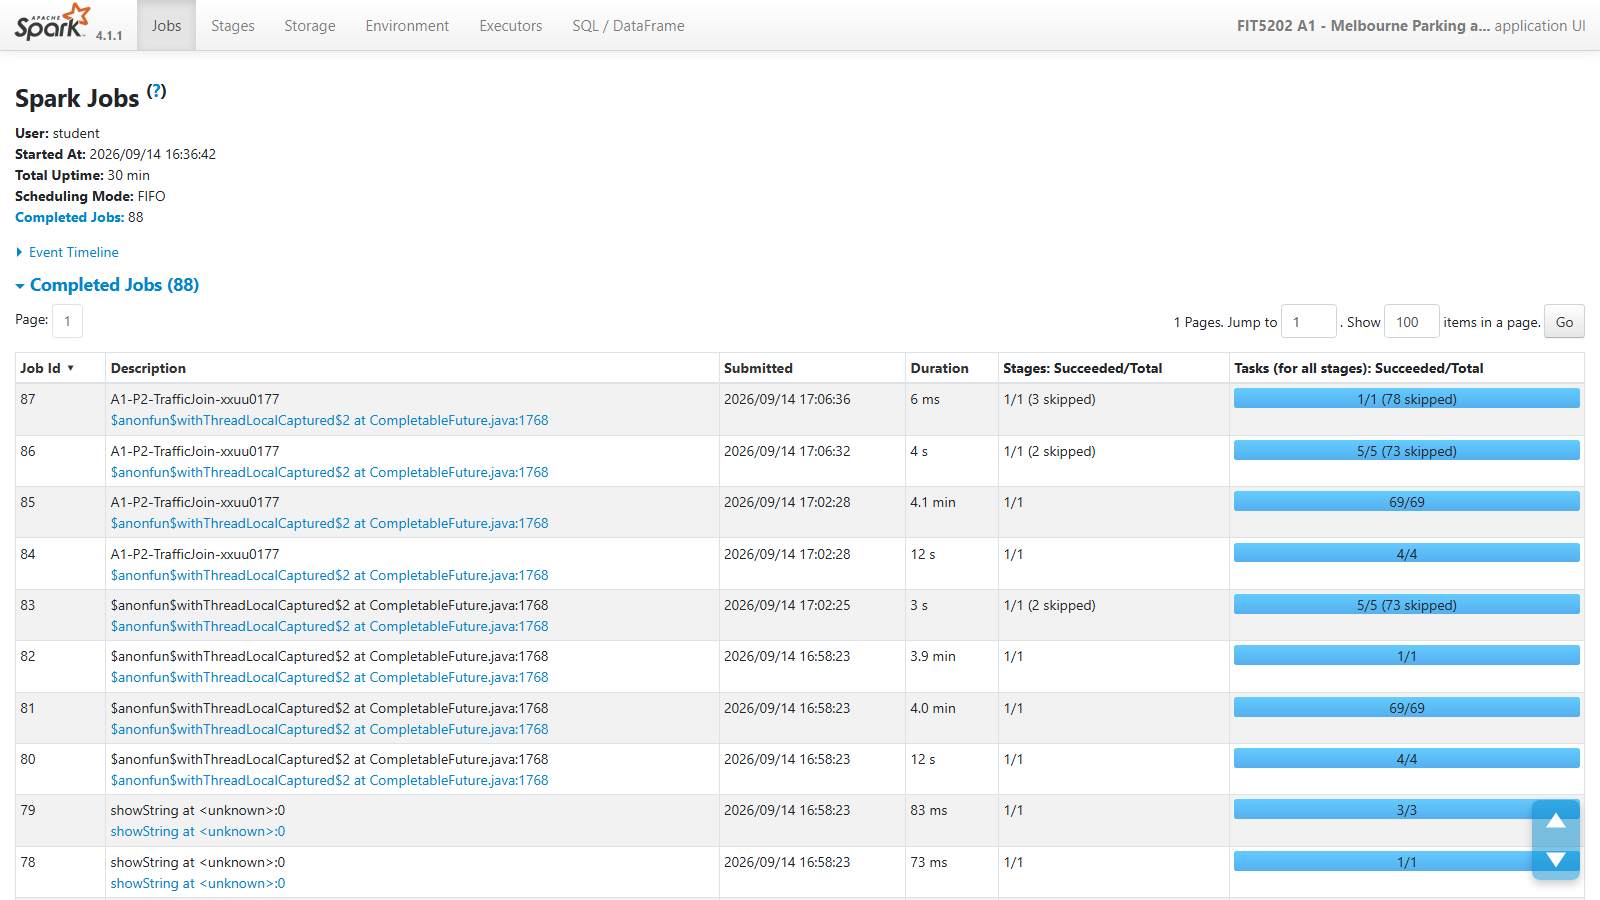

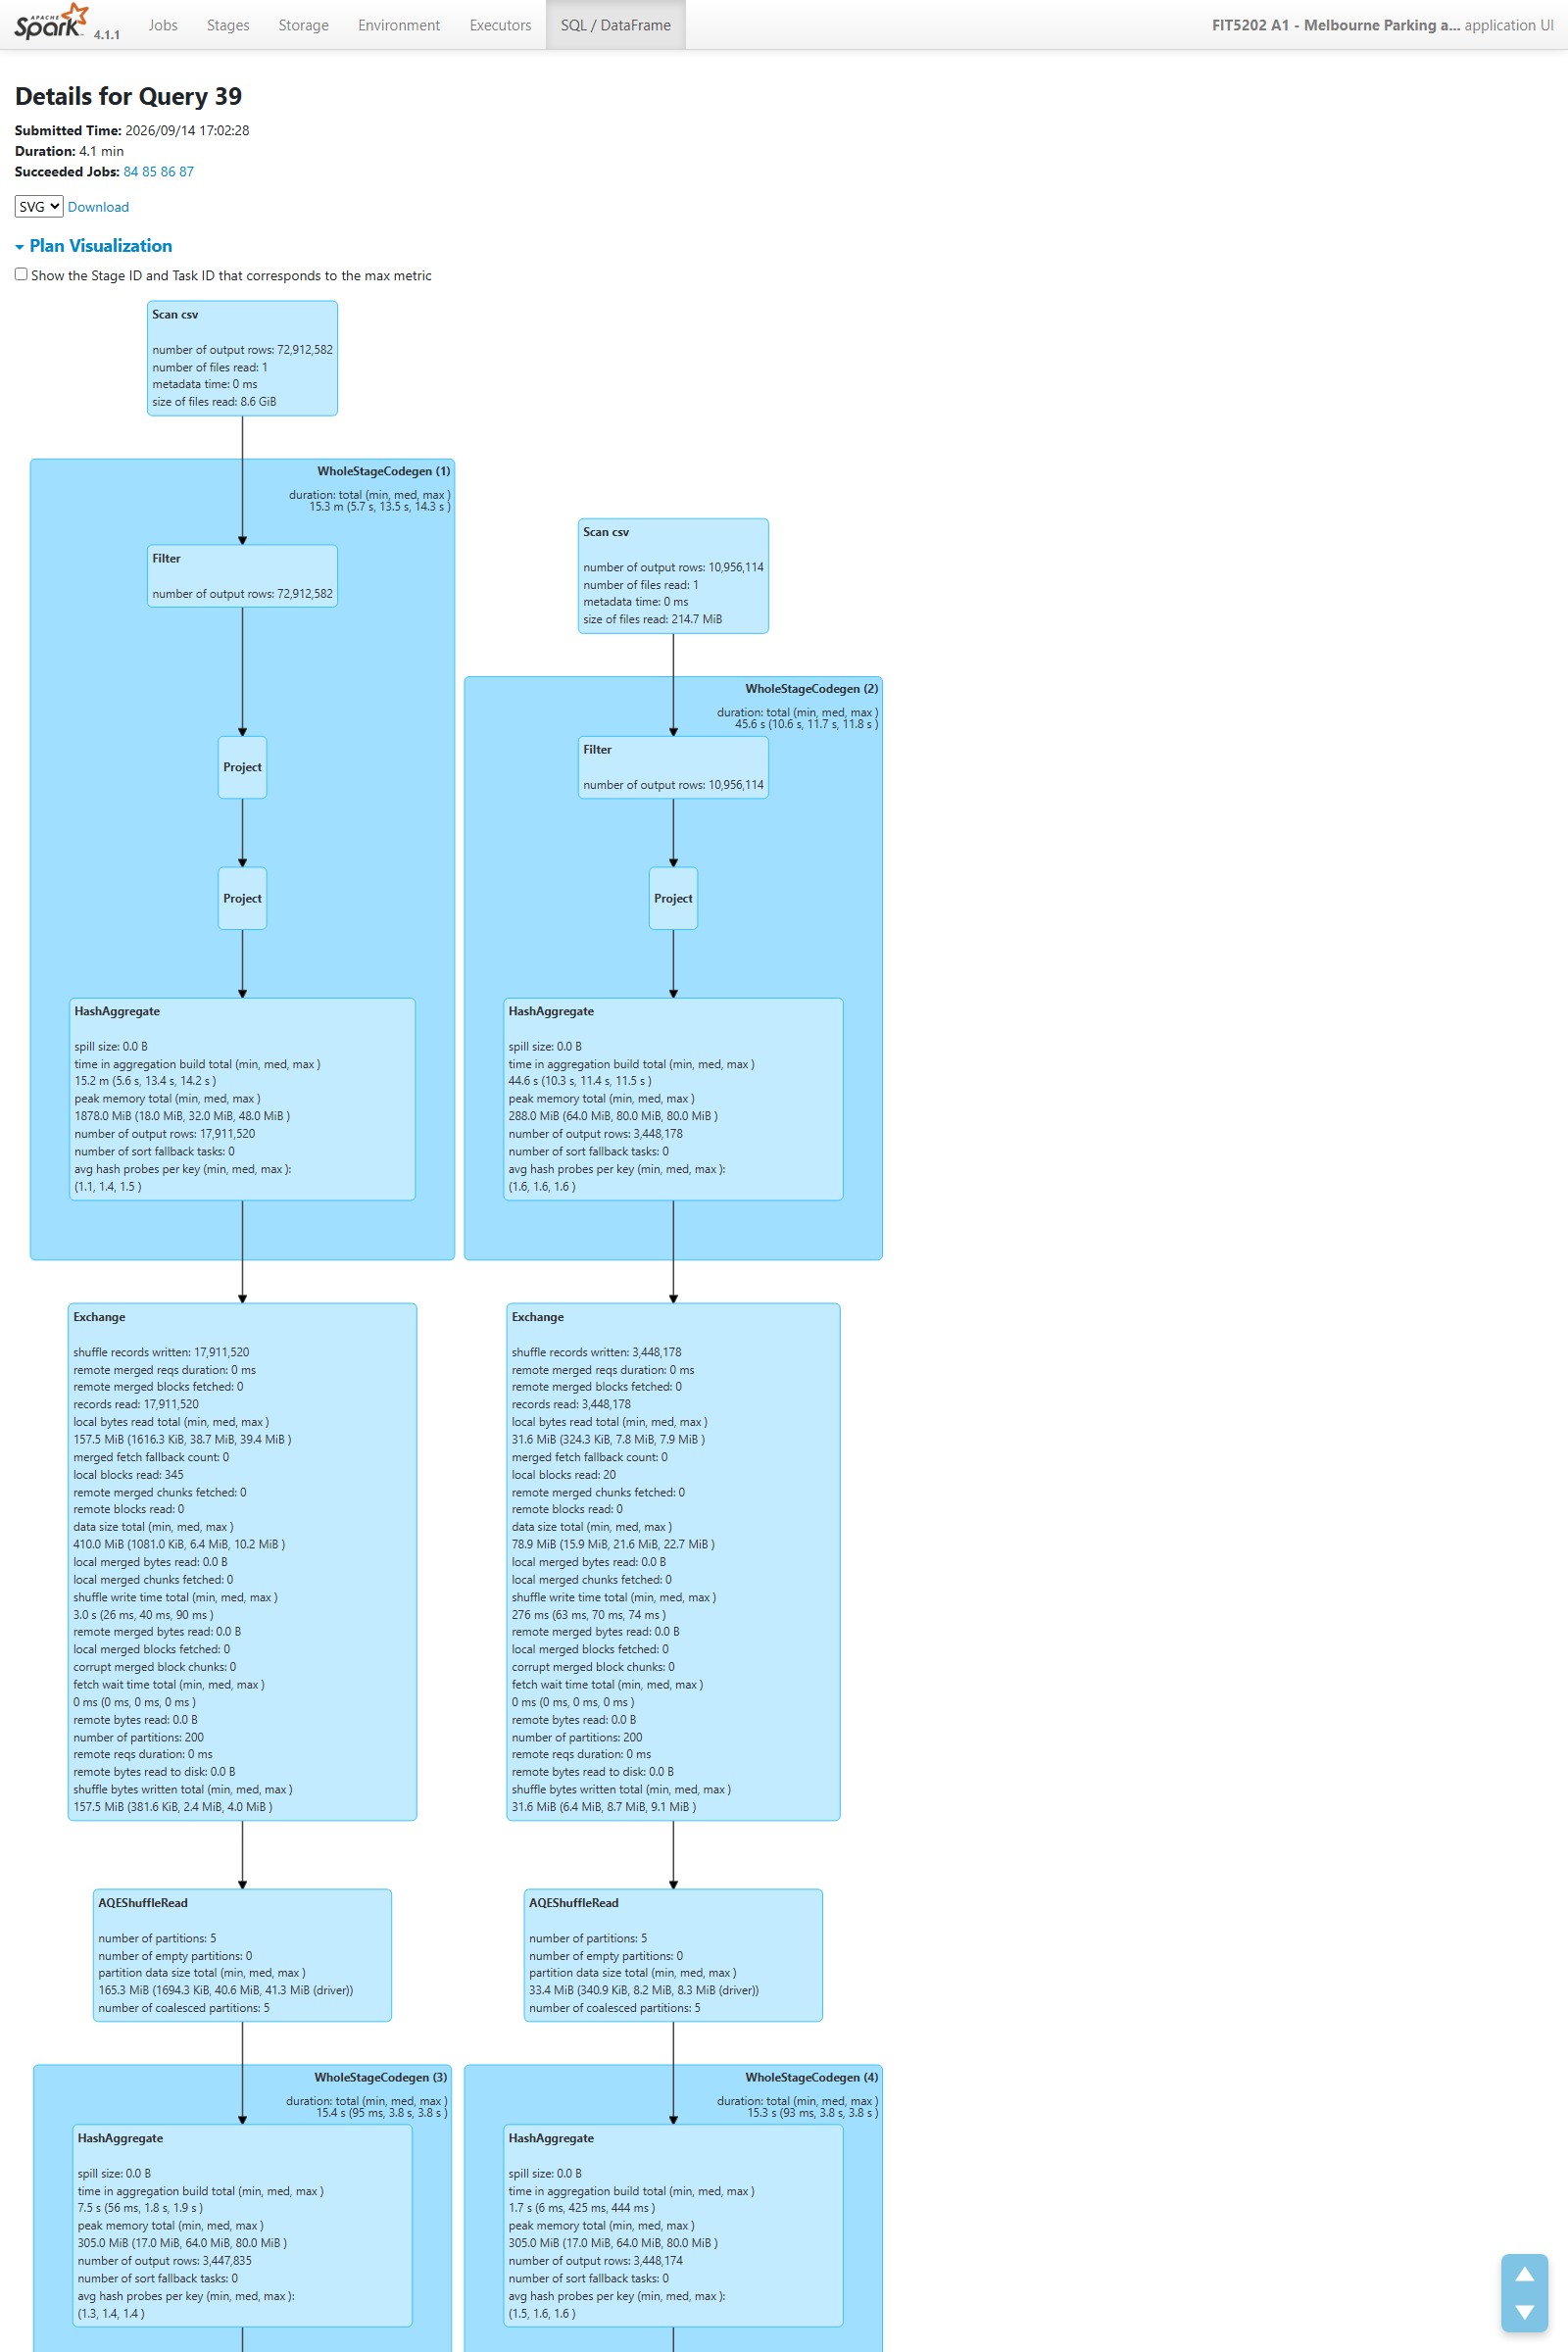

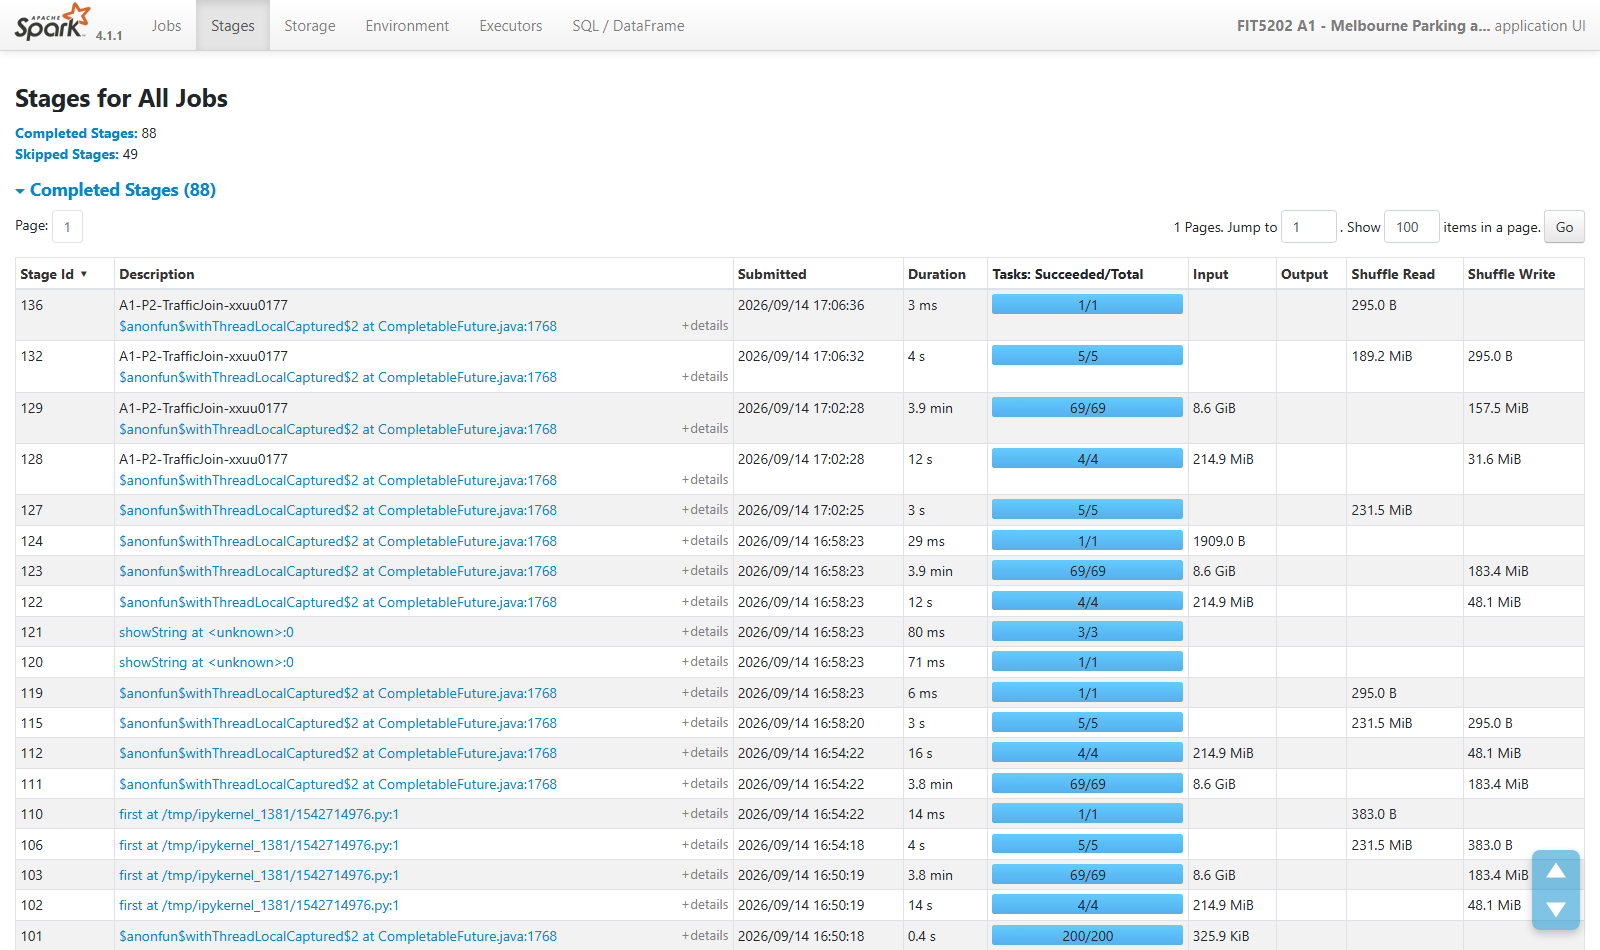

In [27]:
for f in ["p2_jobs.png","p2_sql_dag.png","p2_stages.png"]:
    display(Image(filename="screenshots/"+f))

**Data movement in the traffic join (2.5.4)**

Both inputs are grouped by `(areaid, BlockStart)` and then joined on the same keys, so rows with matching keys must be co-located in the same partition before the join. This corresponds to the disjoint partitioning method described in Week 3, in which both inputs are hash-partitioned on the join attribute, redistributed, and joined locally. The plan shows `Exchange hashpartitioning(areaid, BlockStart, 200)` on each side feeding a `SortMergeJoin Inner`. Broadcasting is not viable here, because the aggregated parking side alone contains 3,447,835 blocks.

The volume of data moved is nonetheless small. In the SQL DAG, the two Exchange nodes report **157.5 MiB** of shuffle bytes written on the parking side and **31.6 MiB** on the traffic side, and the join stage (stage 132) reads **189.2 MiB**, the sum of both. The two-phase aggregation described in Week 4 keeps this volume low: a partial `HashAggregate` runs within each partition before the exchange, so 17,911,520 partially aggregated rows cross the shuffle instead of 72.9 million raw rows, and 3,448,178 rows instead of 11.0 million on the traffic side.

Adaptive Query Execution subsequently coalesces the 200 shuffle partitions into 5 (`AQEShuffleRead`, 5 coalesced partitions), since the aggregated data are far too small to require 200 partitions.

### 2.6 Exploratory analysis  <a class="anchor" name="2.6"></a>
Produce two suitable plots exploring relationships among parking activity, duration, violation rate, or traffic volume.  
For each plot:
1. State the question being investigated;
1. Display the first five rows and the row count of the aggregated dataset used to create the plot
1. Select the appropriate plot type and briefly justify your choice.
1. Explain the observed pattern shown by the plot.
1. identify one limitation of the interpretation.

rows: 38


,AreaId,TotalValidSessions,PeakViolationRate,OffPeakViolationRate
0,1,2277494,1.54,2.60
1,2,284758,2.33,3.27
2,3,3623243,0.78,0.80
3,4,1677102,4.29,3.12
4,5,112274,17.94,8.32


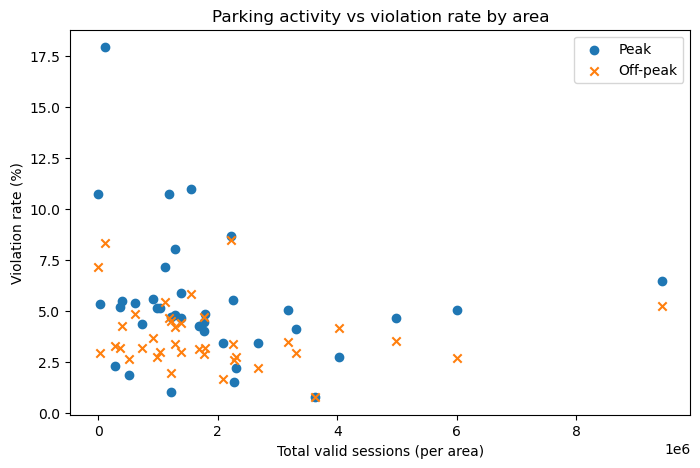

In [28]:
import matplotlib.pyplot as plt
# Plot 1 data: one row per area
p1=res23.select(F.col("areaid").alias("AreaId"),"TotalValidSessions","PeakViolationRate","OffPeakViolationRate")\
    .na.drop().orderBy("AreaId").toPandas()
print("rows:",len(p1))
display(p1.head())

plt.figure(figsize=(8,5))
plt.scatter(p1["TotalValidSessions"],p1["PeakViolationRate"],label="Peak")
plt.scatter(p1["TotalValidSessions"],p1["OffPeakViolationRate"],marker="x",label="Off-peak")
plt.xlabel("Total valid sessions (per area)")
plt.ylabel("Violation rate (%)")
plt.title("Parking activity vs violation rate by area")
plt.legend()
plt.show()

**Plot 1**

1. **Question:** Do areas with more parking activity exhibit higher violation rates, and does the peak rate exceed the off-peak rate within the same area?
2. **Data:** the area-level result from 2.3, with one row per area (38 rows in total; the first five are shown above).
3. **Plot type:** scatter plot. Both variables are numeric and each point represents one area, so a scatter plot shows directly whether the two variables co-vary. Peak and off-peak rates are shown with different markers on shared axes, allowing a within-area comparison.
4. **Pattern:** No clear positive relationship is visible. Most areas record fewer than 2.5 million sessions with violation rates ranging from below 1% to about 18%, and every rate above 10% belongs to an area with fewer than 1.6 million sessions. The busiest area, Docklands (9.4 million sessions), has a moderate peak rate of 6.48%. The peak marker lies above the off-peak marker for most areas, consistent with the comparison in 2.3.
5. **Limitation:** Each point aggregates two years of data for an entire area, and the plot does not account for differences in bay count, parking restrictions or enforcement frequency. Areas with few sessions can also produce extreme rates from a small number of violations. The plot therefore describes an association across areas and should not be interpreted causally.

rows: 24


,hour,AvgParkingSessions,AvgTrafficVolume,blocks
0,0,27.27,282.84,140667
1,1,6.22,50.52,128827
2,2,5.53,45.20,122140
3,3,5.13,43.62,118878
4,4,5.01,42.04,121938


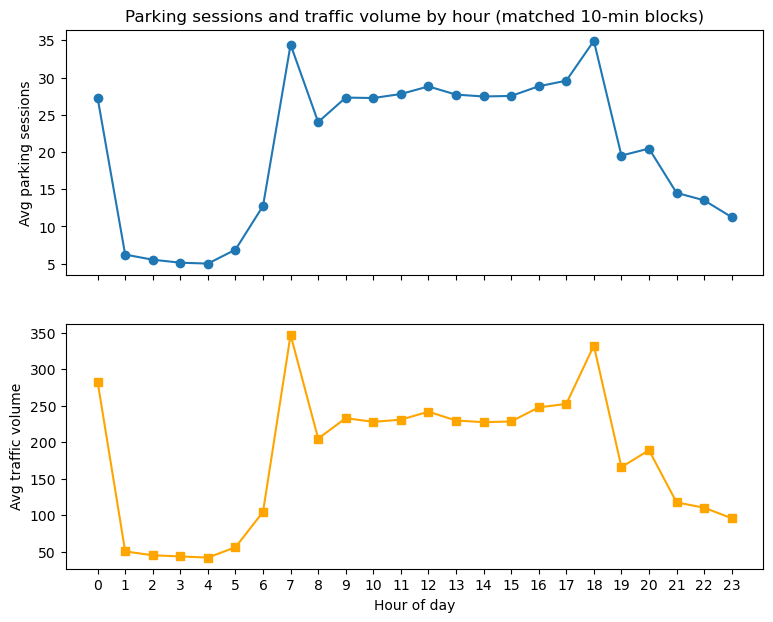

In [29]:
# plot 2 data: the matched area-blocks from 2.5, averaged by hour of day
byhour=combined.groupBy(F.hour("BlockStart").alias("hour")).agg(
    F.round(F.avg("ParkingSessions"),2).alias("AvgParkingSessions"),
    F.round(F.avg("TrafficVolume"),2).alias("AvgTrafficVolume"),F.count("*").alias("blocks"))
p2=byhour.orderBy("hour").toPandas()
print("rows:",len(p2))
display(p2.head())

fig,ax=plt.subplots(2,1,figsize=(9,7),sharex=True)
ax[0].plot(p2["hour"],p2["AvgParkingSessions"],marker="o")
ax[0].set_ylabel("Avg parking sessions")
ax[0].set_title("Parking sessions and traffic volume by hour (matched 10-min blocks)")
ax[1].plot(p2["hour"],p2["AvgTrafficVolume"],marker="s",color="orange")
ax[1].set_ylabel("Avg traffic volume")
ax[1].set_xlabel("Hour of day")
plt.xticks(range(0,24))
plt.show()

**Plot 2**

1. **Question:** Over the course of a day, do parking activity and traffic volume rise and fall together within the matched blocks from 2.5?
2. **Data:** the 3,444,626 matched area-blocks, averaged by hour of day (24 rows in total; the first five are shown above).
3. **Plot type:** two line charts sharing the hour axis. Hour of day is an ordered variable, so a line conveys the daily profile. The two measures differ by an order of magnitude (approximately 5 to 35 sessions against 40 to 350 vehicles per block), so separate panels prevent one series from being flattened against the other's scale.
4. **Pattern:** The two profiles follow nearly identical shapes. Both remain low from 01:00 to 05:00 (about 5 sessions and 45 vehicles per block), rise sharply at 07:00 (about 34 sessions and 350 vehicles), fall at 08:00, hold a plateau from 09:00 to 15:00, reach a second peak at 18:00, and decline towards 23:00. Both peaks fall inside the windows used to define `isPeak`, supporting that definition. Hour 0 is an outlier in both series, which is more consistent with a data artefact, such as timestamps defaulting to 12:00:00 AM, than with genuine demand at midnight.
5. **Limitation:** Averaging over all areas and all days blends busy and quiet areas as well as weekdays and weekends. The shared commuter rhythm also does not establish that parking drives traffic or the reverse, since both are likely responses to a common factor, namely when people travel.

## Part 3 Query Optimisation (25%) <a class="anchor" name="part-3"></a>
Assume that the following monthly parking report will be generated regularly. A correct query is required first, but it should also execute efficiently on the full dataset. In this section, implement the report, inspect how Spark executes it, and evaluate the optimization.

Monthly parking report  
For each month, identify the five areas with the highest number of peak-hour parking sessions among areas whose peak-hour violation rate is greater than the monthly violation benchmark.  
Area Violation Rate = (Peak-hour sessions where inViolation is true) / (Peak-hour sessions with a valid inViolation value) * 100   
Monthly Violation Benchmark = (Peak-hour sessions where InViolation is true across all areas in the month) / (Peak-hour sessions with a valid InViolation value across all areas in the same month) * 100  
  
Display:  
- month;
- area id;
- area name;
- park session count;
- violation count;
- violation rate;
- monthly rank.  
Report the number of months and total result rows, Display the complete result ordered by Month and Monthly Rank in ascending order.

##### 3.1 DataFrame API and Spark SQL <a class="anchor" name="3.1"></a> 
Implement the monthly report independently using:  
1. the PySpark DataFrame API;
2. Spark SQL  
Both implementations must begin with the same prepared input data. Do not create the SQL result by registering the completed DataFrame API result as a temporary view.  
  
Complete the following:  
1. Report the row count returned by each implementation
2. Confirm that the results are identical using exceptAll() in both directions, and display both mismatch counts.
3. For each implementation, display the first 20 result rows using the following column order: 
- Month
- AreaId
- AreaName
- PeakSessionCount
- ViolationCount
- ViolationRate
- MonthlyViolationBenchmark
- MonthlyRank
4. Order the displayed results by Month and MonthlyRank in ascending order.
5. Inspect the physical plan for each implementation, and briefly compare the operations. Briefly explain whether Spark selected different execution strategies, and why?

In [30]:
# prepared input for both versions: valid peak-hour sessions
# data covers 2018 and 2019 so Month keeps the year, month zero-padded as yyyy-MM
mm=F.when(F.col("month")<10,F.concat(F.lit("0"),F.col("month"))).otherwise(F.col("month").cast("string"))
prep=df2.filter(F.col("areaid").isNotNull()&F.col("ArrivalTime").isNotNull()&F.col("isPeak"))\
    .select(F.concat(F.col("year"),F.lit("-"),mm).alias("Month"),F.col("areaid").alias("AreaId"),"InViolation")
prep.createOrReplaceTempView("prep")
areas=df_area_c.select(F.col("areaid").alias("AreaId"),F.col("areaname").alias("AreaName"))
areas.createOrReplaceTempView("area_lk")

w=Window.partitionBy("Month").orderBy(F.desc("PeakSessionCount"),"AreaId")
cols=["Month","AreaId","AreaName","PeakSessionCount","ViolationCount",
      F.round("rate",2).alias("ViolationRate"),F.round("bench",2).alias("MonthlyViolationBenchmark"),"MonthlyRank"]

def by_area():
    return prep.groupBy("Month","AreaId").agg(F.count("*").alias("PeakSessionCount"),
        F.sum(F.when(F.col("InViolation"),1).otherwise(0)).alias("ViolationCount"),
        F.count("InViolation").alias("ValidCount"))

# a function so each timed run gets a new query, not the old shuffle files
def rep_df():
    bench=prep.groupBy("Month").agg(
        (F.sum(F.when(F.col("InViolation"),1).otherwise(0))/F.count("InViolation")*100).alias("bench"))
    return by_area().join(bench,"Month")\
        .withColumn("rate",F.col("ViolationCount")/F.col("ValidCount")*100)\
        .filter(F.col("rate")>F.col("bench"))\
        .withColumn("MonthlyRank",F.row_number().over(w))\
        .filter(F.col("MonthlyRank")<=5)\
        .join(F.broadcast(areas),"AreaId","left")\
        .select(cols).orderBy("Month","MonthlyRank")

res_df=rep_df()

In [31]:
# Spark SQL version, starts from the same prep view (not from the DataFrame result)
res_sql=spark.sql("""
WITH area_m AS (
    SELECT Month, AreaId, COUNT(*) AS PeakSessionCount,
           SUM(CASE WHEN InViolation THEN 1 ELSE 0 END) AS ViolationCount,
           COUNT(InViolation) AS ValidCount
    FROM prep GROUP BY Month, AreaId),
bench AS (
    SELECT Month, SUM(CASE WHEN InViolation THEN 1 ELSE 0 END)/COUNT(InViolation)*100 AS bench
    FROM prep GROUP BY Month),
ranked AS (
    SELECT a.*, a.ViolationCount/a.ValidCount*100 AS rate, b.bench,
           ROW_NUMBER() OVER (PARTITION BY a.Month ORDER BY a.PeakSessionCount DESC, a.AreaId) AS MonthlyRank
    FROM area_m a JOIN bench b ON a.Month=b.Month
    WHERE a.ViolationCount/a.ValidCount*100 > b.bench)
SELECT r.Month, r.AreaId, l.AreaName, r.PeakSessionCount, r.ViolationCount,
       ROUND(r.rate,2) AS ViolationRate, ROUND(r.bench,2) AS MonthlyViolationBenchmark, r.MonthlyRank
FROM ranked r LEFT JOIN area_lk l ON r.AreaId=l.AreaId
WHERE r.MonthlyRank<=5
ORDER BY r.Month, r.MonthlyRank
""")

In [32]:
print("==== DataFrame API plan ====")
res_df.explain(mode="formatted")

==== DataFrame API plan ====


== Physical Plan ==
AdaptiveSparkPlan (38)
+- Sort (37)
   +- Exchange (36)
      +- Project (35)
         +- BroadcastHashJoin LeftOuter BuildRight (34)
            :- Filter (27)
            :  +- Window (26)
            :     +- WindowGroupLimit (25)
            :        +- Sort (24)
            :           +- Project (23)
            :              +- SortMergeJoin Inner (22)
            :                 :- Sort (11)
            :                 :  +- Exchange (10)
            :                 :     +- Filter (9)
            :                 :        +- HashAggregate (8)
            :                 :           +- Exchange (7)
            :                 :              +- HashAggregate (6)
            :                 :                 +- Project (5)
            :                 :                    +- Project (4)
            :                 :                       +- Project (3)
            :                 :                          +- Filter (2)
            :        

In [33]:
print("==== Spark SQL plan ====")
res_sql.explain(mode="formatted")

==== Spark SQL plan ====


== Physical Plan ==
AdaptiveSparkPlan (38)
+- Sort (37)
   +- Exchange (36)
      +- Project (35)
         +- BroadcastHashJoin LeftOuter BuildRight (34)
            :- Filter (27)
            :  +- Window (26)
            :     +- WindowGroupLimit (25)
            :        +- Sort (24)
            :           +- Project (23)
            :              +- SortMergeJoin Inner (22)
            :                 :- Sort (11)
            :                 :  +- Exchange (10)
            :                 :     +- Filter (9)
            :                 :        +- HashAggregate (8)
            :                 :           +- Exchange (7)
            :                 :              +- HashAggregate (6)
            :                 :                 +- Project (5)
            :                 :                    +- Project (4)
            :                 :                       +- Project (3)
            :                 :                          +- Filter (2)
            :        

In [34]:
# cache both results (small) so the checks below don't run the query again
r1=res_df.cache()
r2=res_sql.cache()
print("DataFrame API rows:",r1.count())
print("Spark SQL rows:",r2.count())
print("rows in DF result but not in SQL result:",r1.exceptAll(r2).count())
print("rows in SQL result but not in DF result:",r2.exceptAll(r1).count())

DataFrame API rows: 120


Spark SQL rows: 120


rows in DF result but not in SQL result: 0


rows in SQL result but not in DF result: 0


In [35]:
print("DataFrame API - first 20 rows")
r1.orderBy("Month","MonthlyRank").show(20,truncate=False)
print("Spark SQL - first 20 rows")
r2.orderBy("Month","MonthlyRank").show(20,truncate=False)

DataFrame API - first 20 rows


+-------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|Month  |AreaId|AreaName       |PeakSessionCount|ViolationCount|ViolationRate|MonthlyViolationBenchmark|MonthlyRank|
+-------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|2018-01|35    |Docklands      |85792           |5606          |6.53         |5.34                     |1          |
|2018-01|38    |Southbank      |45155           |2470          |5.47         |5.34                     |2          |
|2018-01|6     |Titles         |19818           |1115          |5.63         |5.34                     |3          |
|2018-01|13    |Princes Theatre|17223           |1252          |7.27         |5.34                     |4          |
|2018-01|20    |Courtney       |12275           |1605          |13.08        |5.34                     |5          |
|2018-02|35    |Docklands      |80425           |5689          |

+-------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|Month  |AreaId|AreaName       |PeakSessionCount|ViolationCount|ViolationRate|MonthlyViolationBenchmark|MonthlyRank|
+-------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|2018-01|35    |Docklands      |85792           |5606          |6.53         |5.34                     |1          |
|2018-01|38    |Southbank      |45155           |2470          |5.47         |5.34                     |2          |
|2018-01|6     |Titles         |19818           |1115          |5.63         |5.34                     |3          |
|2018-01|13    |Princes Theatre|17223           |1252          |7.27         |5.34                     |4          |
|2018-01|20    |Courtney       |12275           |1605          |13.08        |5.34                     |5          |
|2018-02|35    |Docklands      |80425           |5689          |

In [36]:
n=r1.count()
print("number of months:",r1.select("Month").distinct().count())
print("total result rows:",n)
r1.orderBy("Month","MonthlyRank").show(n,truncate=False)

number of months: 24
total result rows: 120


+-------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|Month  |AreaId|AreaName       |PeakSessionCount|ViolationCount|ViolationRate|MonthlyViolationBenchmark|MonthlyRank|
+-------+------+---------------+----------------+--------------+-------------+-------------------------+-----------+
|2018-01|35    |Docklands      |85792           |5606          |6.53         |5.34                     |1          |
|2018-01|38    |Southbank      |45155           |2470          |5.47         |5.34                     |2          |
|2018-01|6     |Titles         |19818           |1115          |5.63         |5.34                     |3          |
|2018-01|13    |Princes Theatre|17223           |1252          |7.27         |5.34                     |4          |
|2018-01|20    |Courtney       |12275           |1605          |13.08        |5.34                     |5          |
|2018-02|35    |Docklands      |80425           |5689          |

**Comparison of physical plans (3.1.5)**

The two formatted plans share the **same structure**, with the same 38 operators in the same order, indicating that Spark selected the same execution strategy for both implementations. The only textual difference is the position of the `rate` and `bench` columns within several `Project` nodes, which changes column order but not the operations performed.

- **Two scans of the CSV file** (`Scan csv (1)` and `Scan csv (12)`) feed two aggregation branches. In each branch, a `Filter` keeps valid peak-hour rows, three `Project` nodes derive `ArrivalTime`, `year` and `month` and then the `Month` key, followed by the two-phase parallel GroupBy described in Week 4: a partial `HashAggregate` within each partition, an `Exchange` that redistributes rows by the grouping key, and a final `HashAggregate`. The area branch is hash-partitioned on `(Month, AreaId)` and the benchmark branch on `Month`.
- **The branches are joined** by a `SortMergeJoin` on `Month`, after the area branch is repartitioned by `Month` (`Exchange (10)`). This reflects disjoint partitioning, since both inputs are aggregates rather than a small lookup table.
- **The window** (`ROW_NUMBER()` per month) requires no further exchange, since the join output is already partitioned by `Month`; only a local `Sort (24)` by `Month`, `PeakSessionCount` and `AreaId` is added. Spark also inserts `WindowGroupLimit (25)` ahead of the `Window`, derived from the `MonthlyRank <= 5` filter, so each month retains only its first five rows.
- **Area names** are attached through `BroadcastHashJoin (LeftOuter, BuildRight)`, the Divide and Broadcast method, because the area table occupies only a few KB. The DataFrame version requests the broadcast explicitly with `F.broadcast`, while the SQL version obtains it automatically because the table falls below `spark.sql.autoBroadcastJoinThreshold` (10 MB).

The plans coincide because the DataFrame calls and the SQL text are translated into equivalent logical plans, which pass through the same Catalyst optimiser and physical planner. The physical plans would diverge only if the query logic differed or a different join hint were applied.

##### 3.2 Baseline plan and Spark UI analysis <a class="anchor" name="3.2"></a>  
Select either SQL or DataFrame API from Section 3.1 as a baseline. Clearly state which implementation you selected.  
Before running the baseline query, set: sc.setJobDescription(f"A1-P3-2-Baseline-{student_auth_code}")  
Execute an action that materialises the complete final result and record the wall-clock execution time. Use the same action later when evaluating the optimised query.  
Submit and include:  
- the formatted physical plan, you may refer to the plan already printed in Section 3.1 rather than printing it again.
- Spark UI screenshots clearly showing: the job description, the SQL/DAG, the relevant stage details, relevant shuffle-read, shuffle-write figures, where applicable.
- the measured execution time;  
In no more than 300 words:  
1. Identify the most expensive stages or operations.
2. Support the explanation using numbers visible in your screenshots.
3. Suggest an improvement strategy.

In [37]:
import time
spark.catalog.clearCache()   # nothing cached, so the timing is a real run
print("Baseline = DataFrame API version (rep_df). Action = collect() of the complete result.")
q=rep_df()
sc.setJobDescription(f"A1-P3-2-Baseline-{student_auth_code}")
t0=time.perf_counter()
base_rows=q.collect()
t_base=time.perf_counter()-t0
sc.setJobDescription(None)
print("baseline result rows:",len(base_rows))
print(f"baseline wall-clock time: {t_base:.2f} s")

Baseline = DataFrame API version (rep_df). Action = collect() of the complete result.


baseline result rows: 120
baseline wall-clock time: 761.86 s


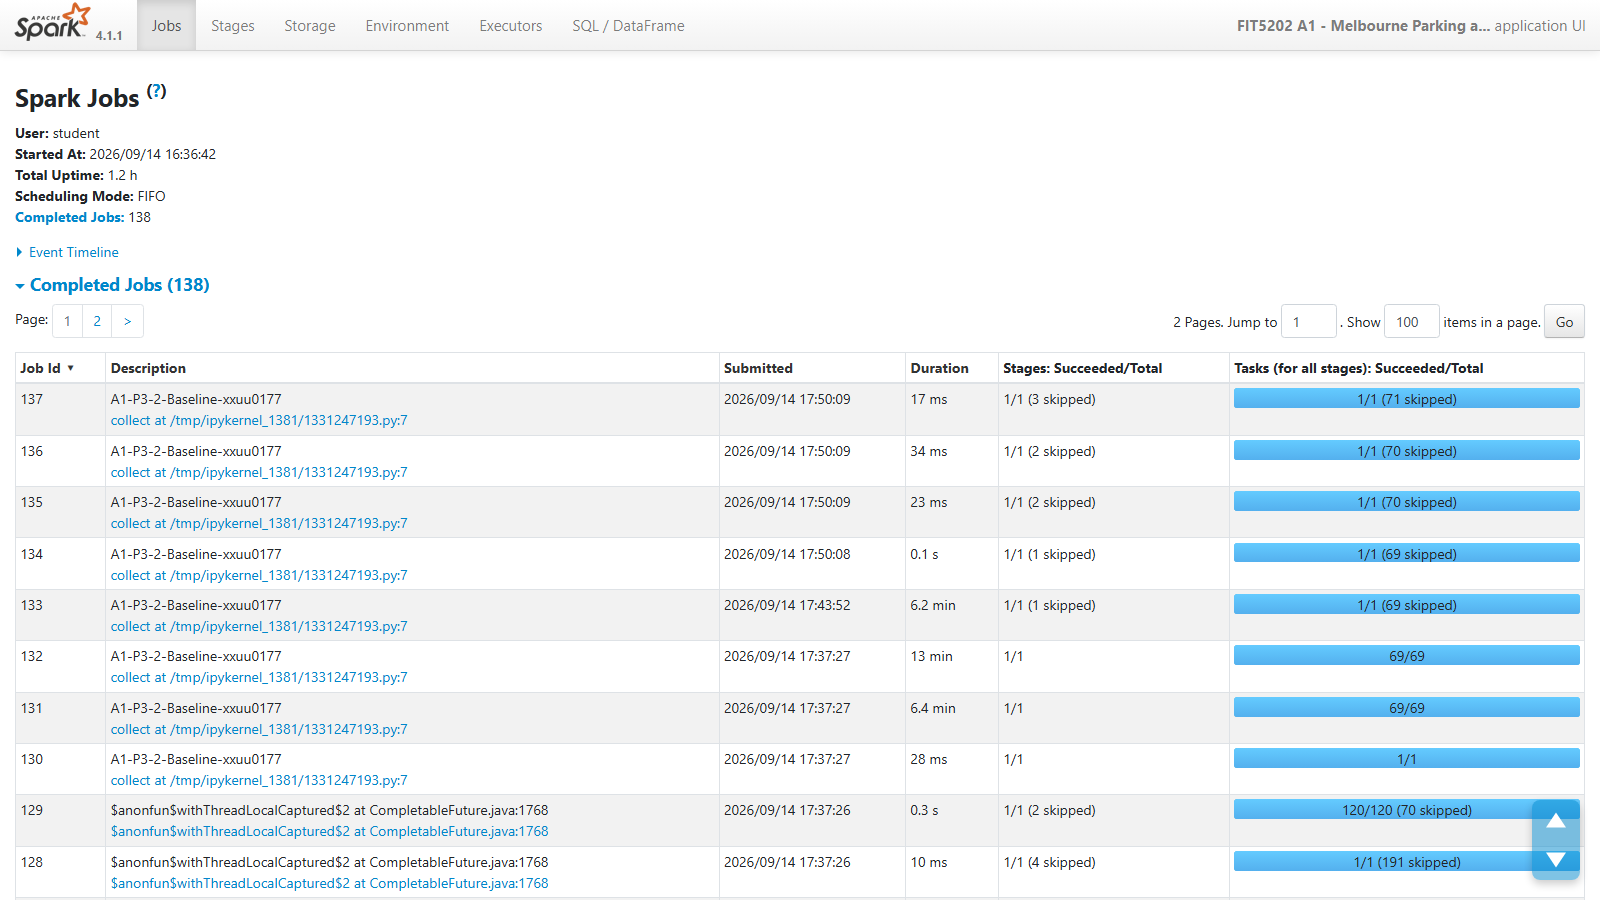

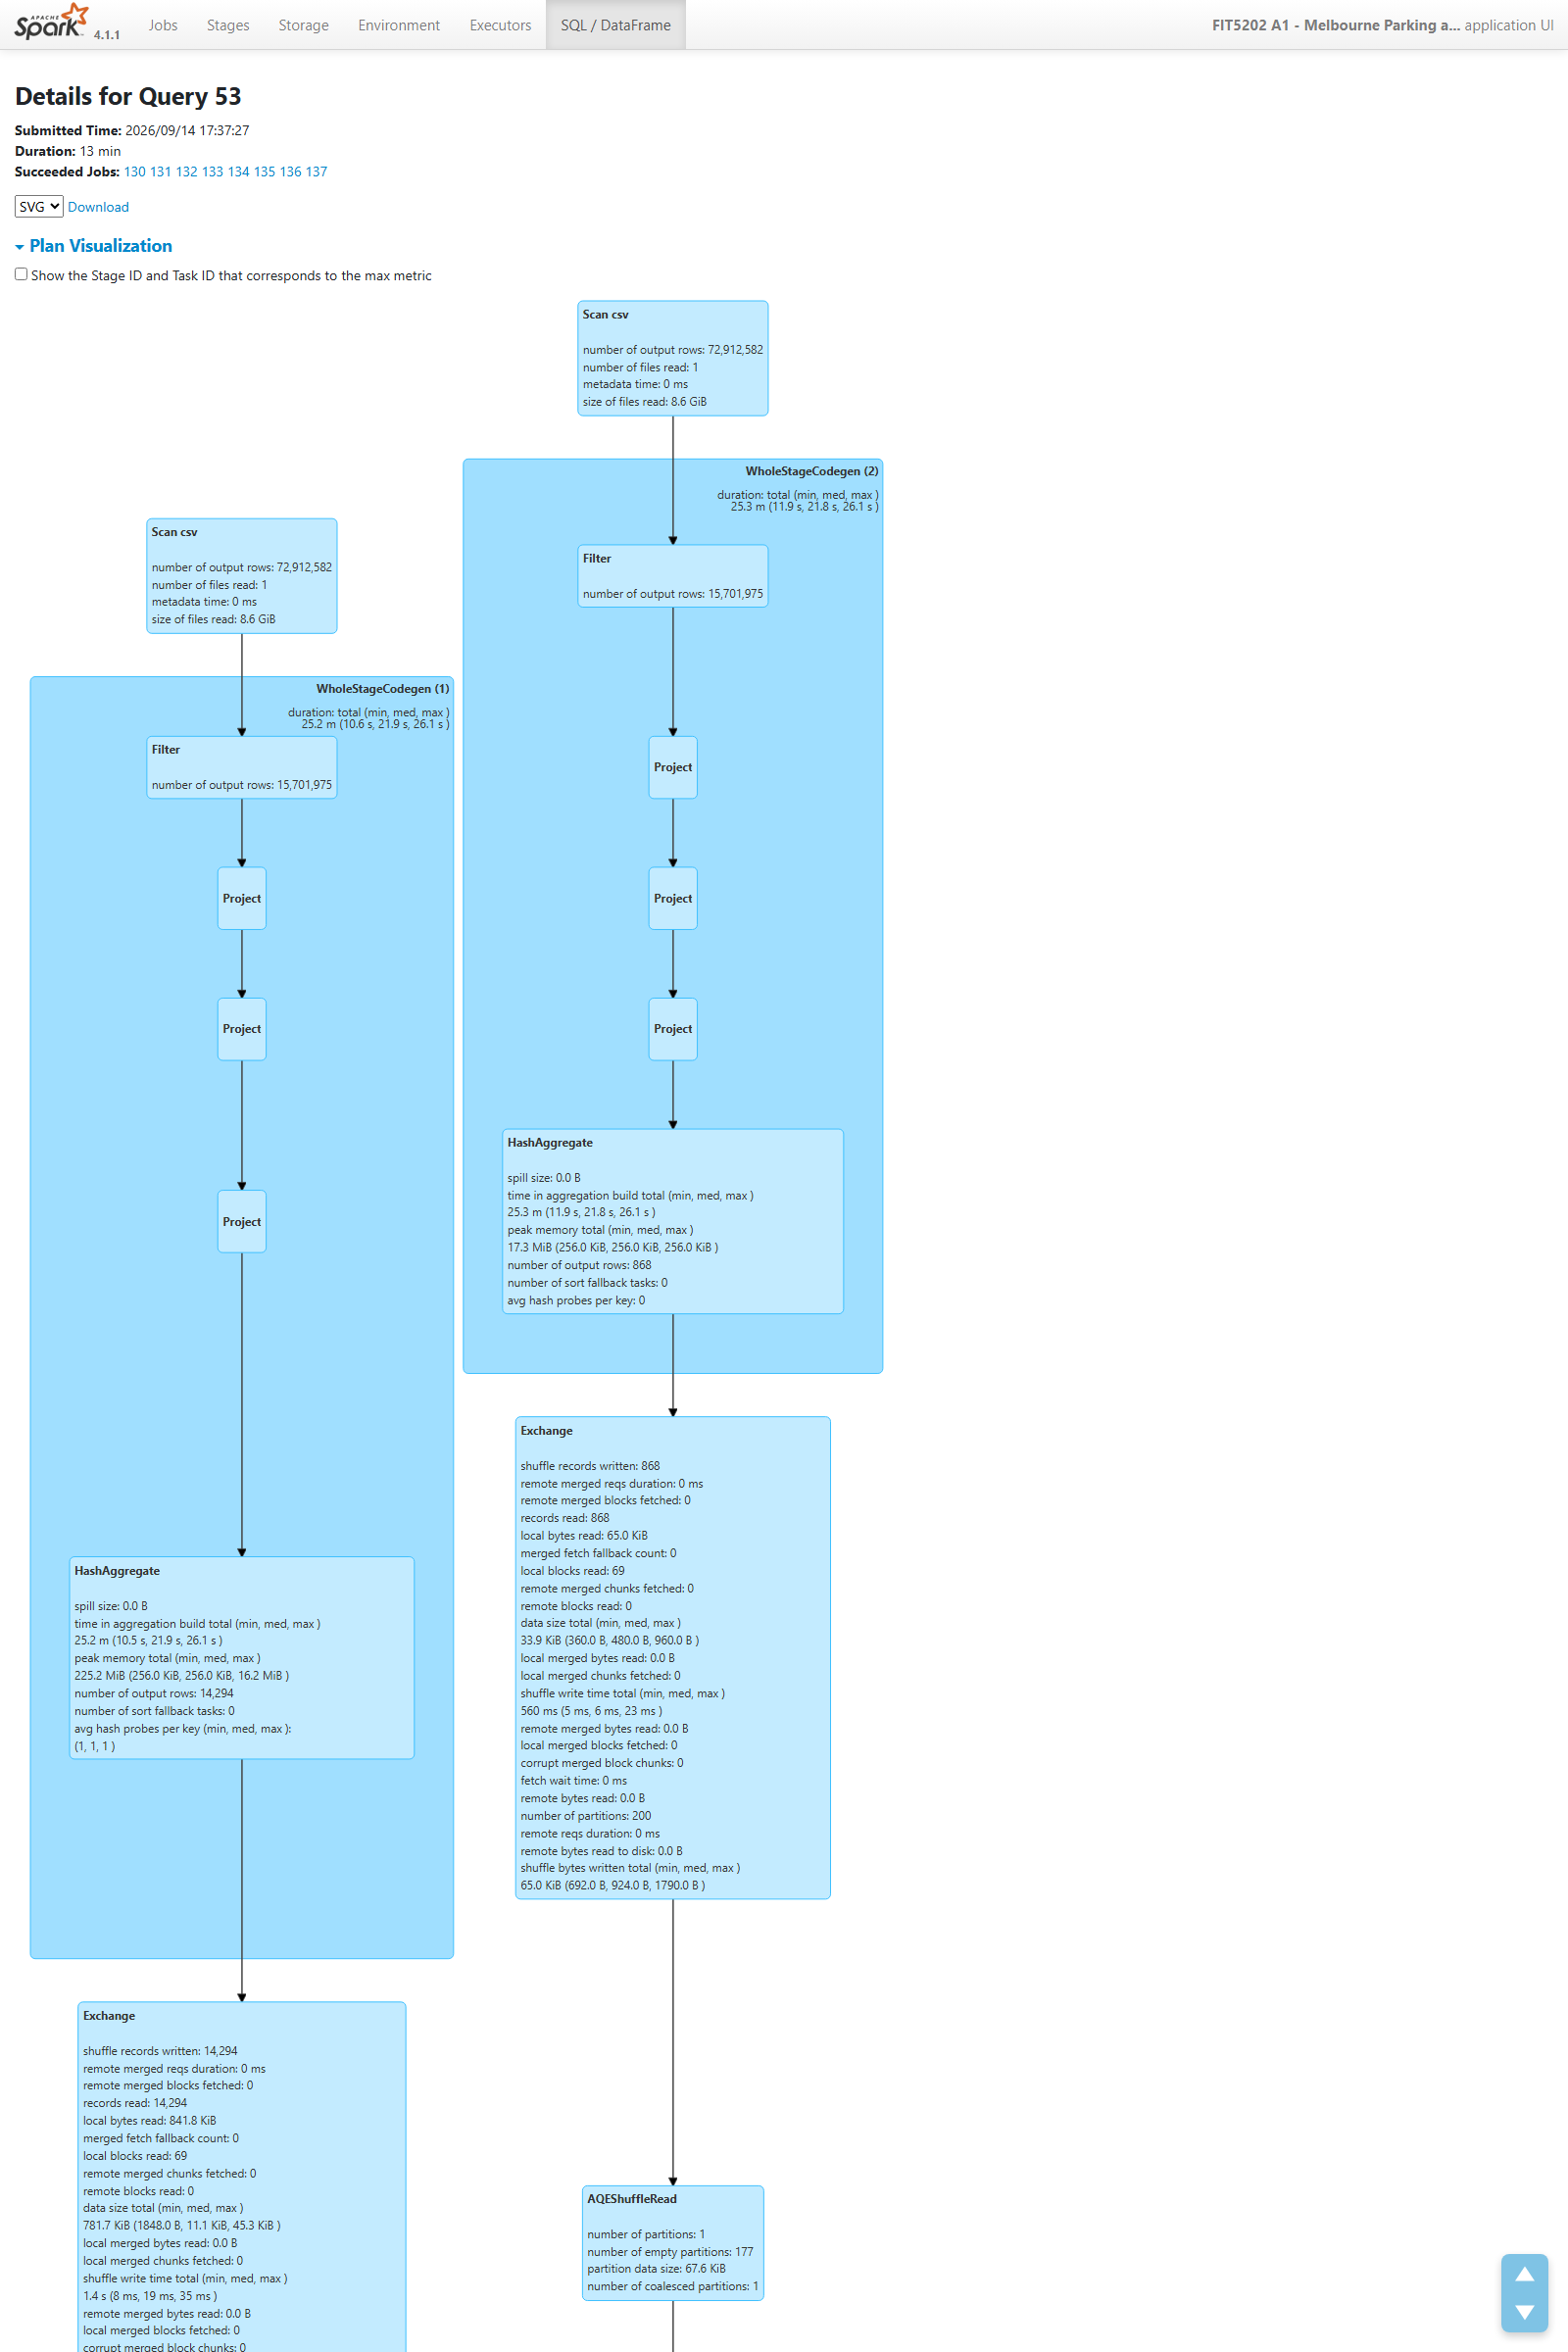

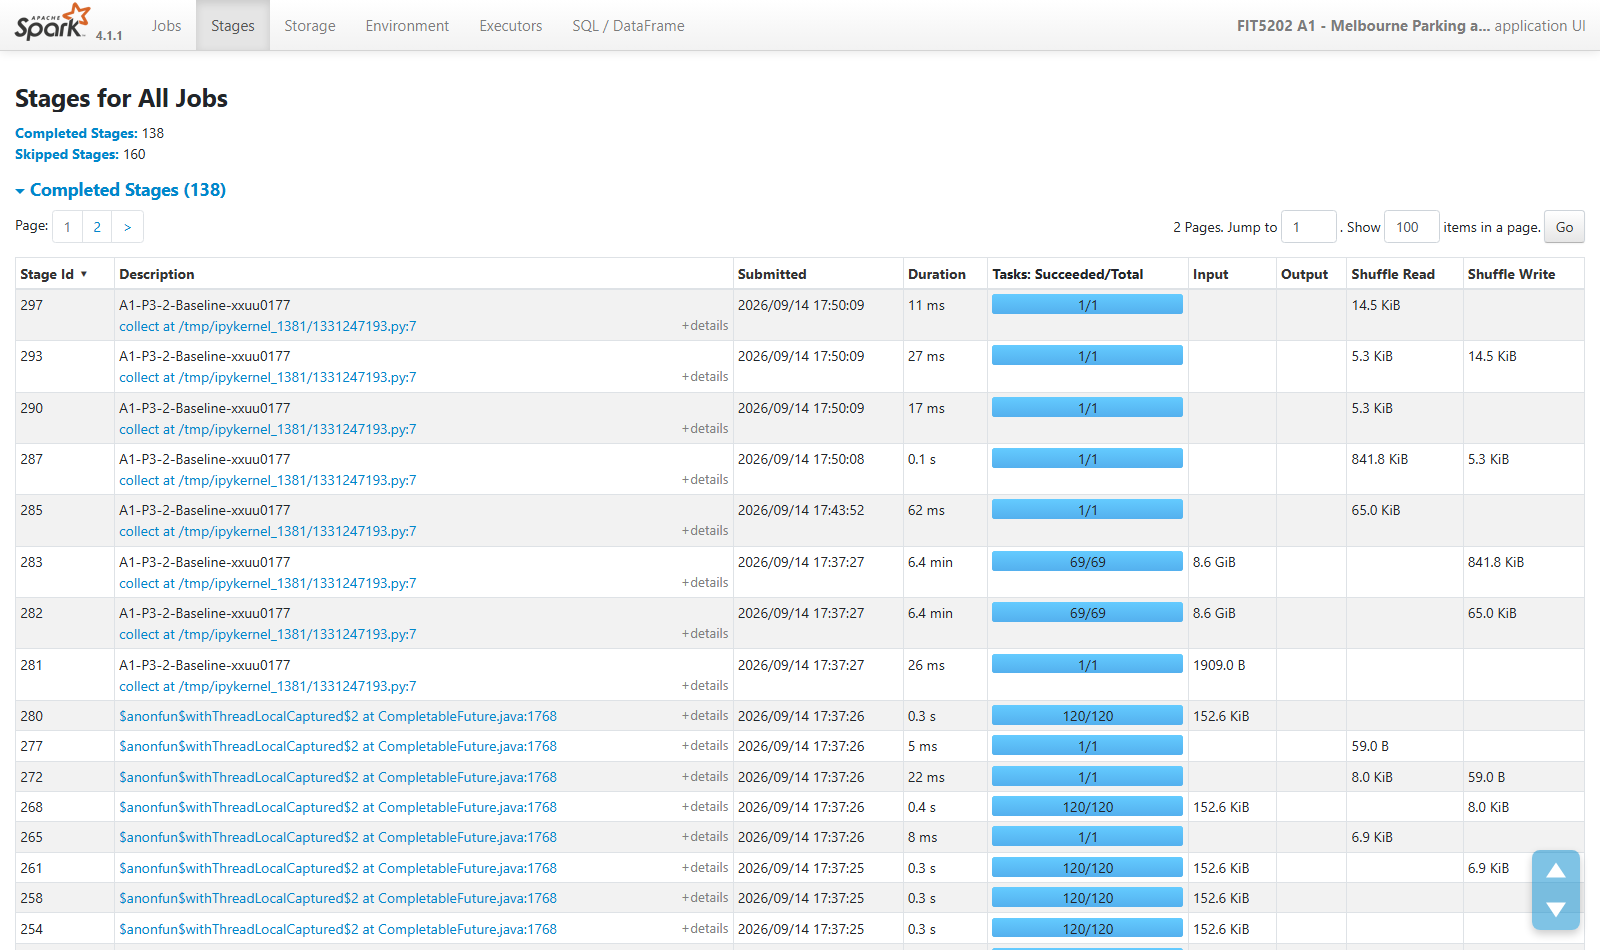

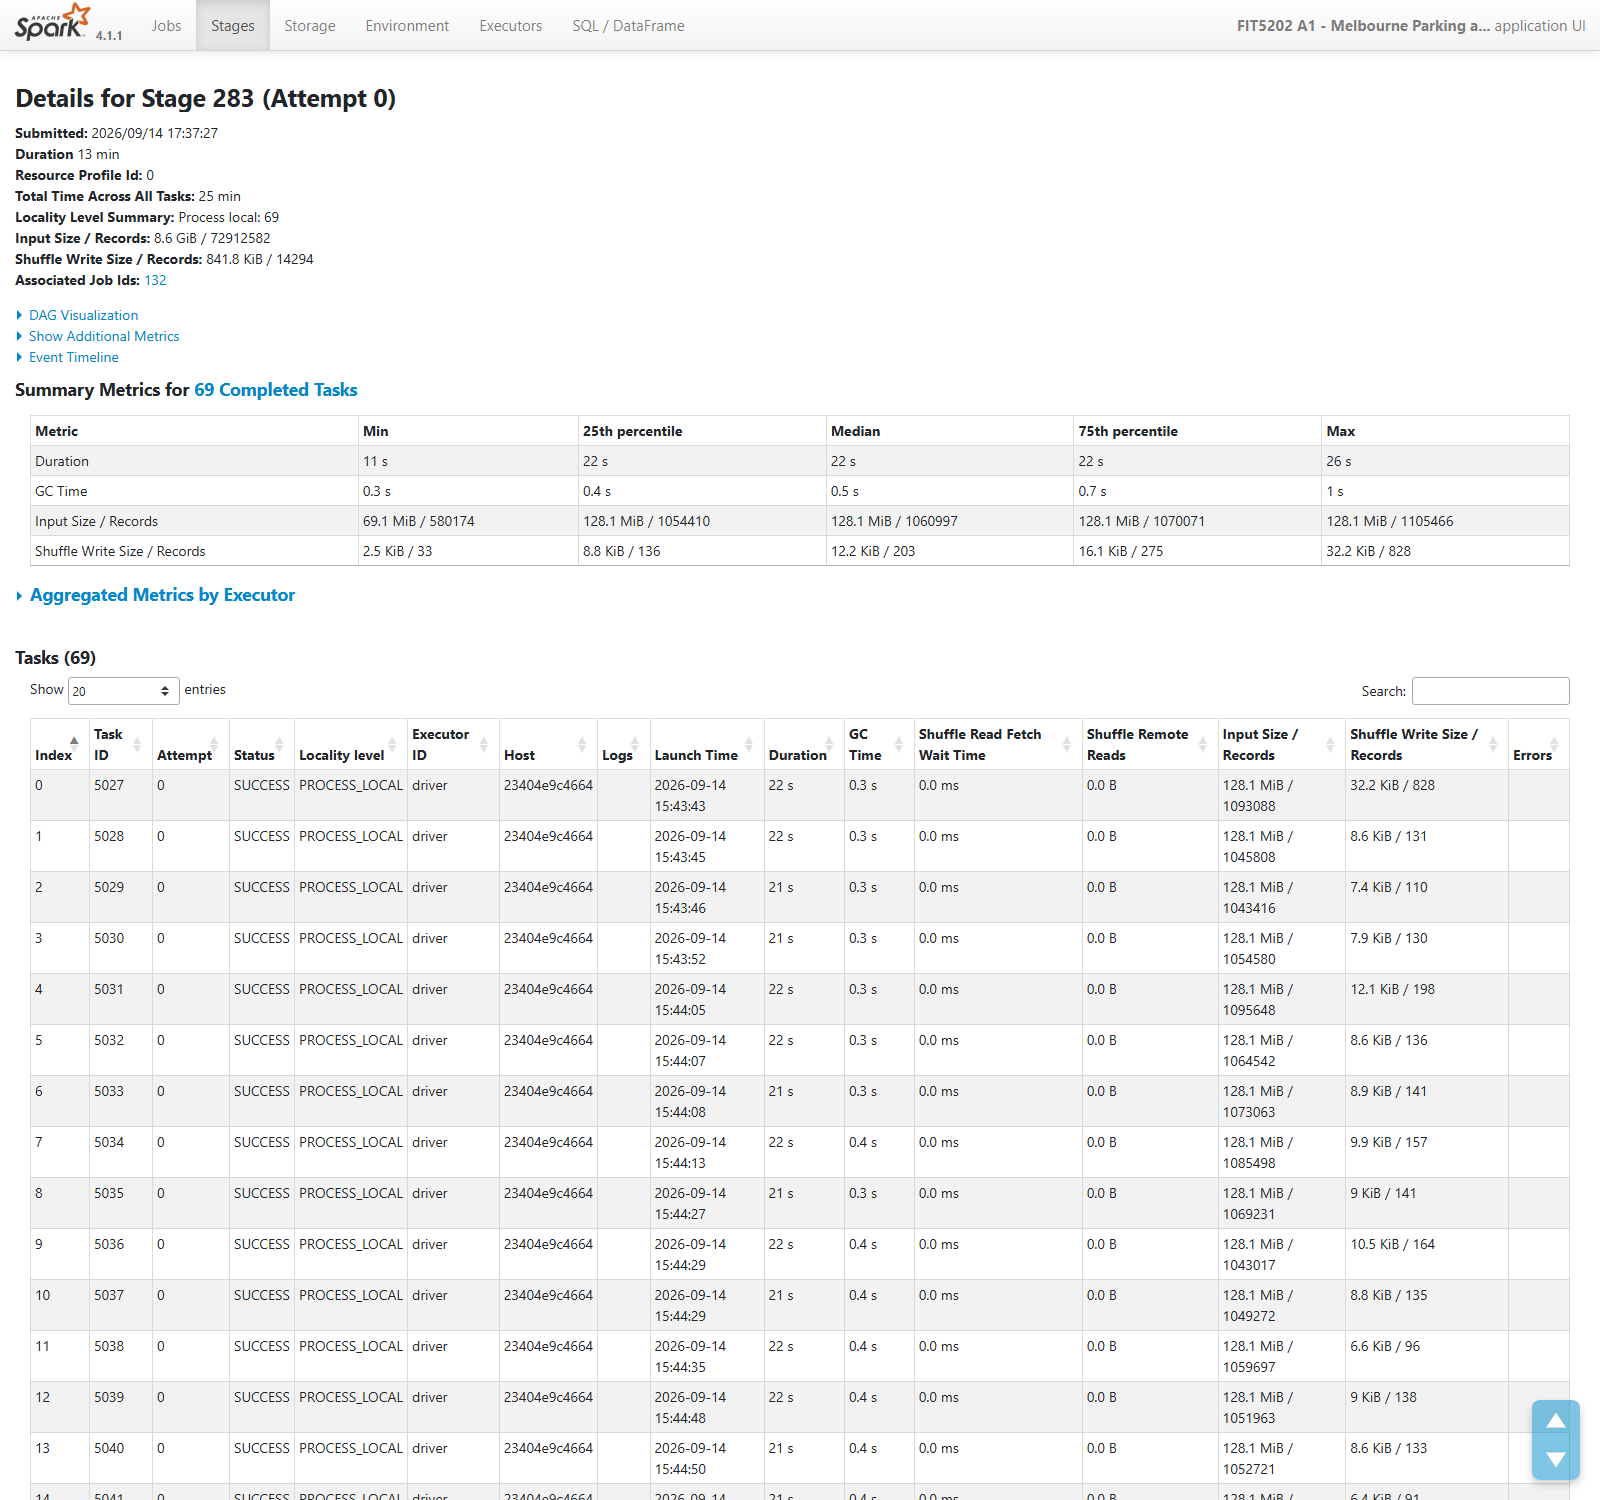

In [38]:
for f in ["p32_jobs.png","p32_sql_dag.png","p32_stages.png","p32_stage_tasks.png"]:
    display(Image(filename="screenshots/"+f))

**Baseline analysis (3.2)**

**Selected implementation:** DataFrame API (`rep_df()`), materialised with `collect()`, as used again in 3.3; the formatted plan appears in 3.1.

**Measured execution time: 761.86 s.**

| Stage | Tasks | Input | Duration | Shuffle read | Shuffle write |
|---|---|---|---|---|---|
| 282 (monthly benchmark scan) | 69 | 8.6 GiB | 6.4 min | - | 65.0 KiB |
| 283 (area-month scan) | 69 | 8.6 GiB | 6.4 min | - | 841.8 KiB |
| 285, 287, 290, 293, 297 (aggregation, join, window, sort) | 1 each | - | 11 ms to 0.1 s | 5.3 to 841.8 KiB | 14.5 KiB or less |

**Most expensive operations.** The two full CSV scans dominate the job. Both stages are submitted at 17:37:27, but their tasks share the same four cores, so stage 283 shows a 6.4 min duration in the Spark UI within a 13 min stage lifetime. Every later stage finishes within 0.1 s, so the scans account for nearly all of the 762 s total. The 69 tasks of stage 283 (median 22 s) total 25 min of cumulative task time, since each reads a 128.1 MiB split of the 9.2 GB file and parses its timestamps.

**Shuffle is not the bottleneck.** Partial aggregation reduces 72,912,582 rows to 14,294 shuffle records in stage 283 before any data movement, so the scans write only 65.0 KiB and 841.8 KiB. The job is therefore bound by file reading and parsing rather than by data movement.

**Improvement strategy.** The second scan can be removed: the monthly benchmark equals the sum of the per-area monthly counts, so a window sum over `Month` on the area-month aggregate reproduces it without re-aggregating the raw rows, which should roughly halve file reading and timestamp parsing, the dominant cost.

##### 3.3 Evaluate one optimisation <a class="anchor" name="3.3"></a>  
Implement one optimisation based on the evidence and reasoning presented in Section 3.2. Briefly state what you changed and why you expect it to improve execution.  
Before executing it, set: sc.setJobDescription(f"A1-P3-3-Optimised-{student_auth_code}")  
Then:  
1. Run the baseline and revised queries under the same conditions;
2. Confirm that the optimised query produces exactly the same result as the baseline
3. Record the execution time and collect the corresponding Spark UI evidence.
4. Decide whether the optimisation should be retained, justify your decision.
5. A technically reasonable improvement and evidence-based evaluation are required for full marks.

In [39]:
# benchmark from a window sum over the area-month counts, so the csv is scanned once
wm=Window.partitionBy("Month")

def rep_opt():
    return by_area().withColumn("bench",F.sum("ViolationCount").over(wm)/F.sum("ValidCount").over(wm)*100)\
        .withColumn("rate",F.col("ViolationCount")/F.col("ValidCount")*100)\
        .filter(F.col("rate")>F.col("bench"))\
        .withColumn("MonthlyRank",F.row_number().over(w))\
        .filter(F.col("MonthlyRank")<=5)\
        .join(F.broadcast(areas),"AreaId","left")\
        .select(cols).orderBy("Month","MonthlyRank")

res_opt=rep_opt()
res_opt.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (28)
+- Sort (27)
   +- Exchange (26)
      +- Project (25)
         +- BroadcastHashJoin LeftOuter BuildRight (24)
            :- Filter (17)
            :  +- Window (16)
            :     +- WindowGroupLimit (15)
            :        +- Sort (14)
            :           +- Project (13)
            :              +- Filter (12)
            :                 +- Window (11)
            :                    +- Sort (10)
            :                       +- Exchange (9)
            :                          +- HashAggregate (8)
            :                             +- Exchange (7)
            :                                +- HashAggregate (6)
            :                                   +- Project (5)
            :                                      +- Project (4)
            :                                         +- Project (3)
            :                                            +- Filter (2)
            :                     

In [40]:
# same conditions: same session, nothing cached, fresh queries, same action
spark.catalog.clearCache()
qb,qo=rep_df(),rep_opt()
sc.setJobDescription(f"A1-P3-3-BaselineRerun-{student_auth_code}")
t0=time.perf_counter()
rows_b=qb.collect()
tb=time.perf_counter()-t0

sc.setJobDescription(f"A1-P3-3-Optimised-{student_auth_code}")
t0=time.perf_counter()
rows_o=qo.collect()
to=time.perf_counter()-t0
sc.setJobDescription(None)

print(f"baseline (3.2 run): {t_base:.2f} s")
print(f"baseline (rerun)  : {tb:.2f} s")
print(f"optimised         : {to:.2f} s")
print(f"speed-up vs rerun : {tb/to:.2f}x")

baseline (3.2 run): 761.86 s
baseline (rerun)  : 795.74 s
optimised         : 230.11 s
speed-up vs rerun : 3.46x


In [41]:
b=spark.createDataFrame(rows_b,res_df.schema)
o=spark.createDataFrame(rows_o,res_opt.schema)
print("baseline rows:",len(rows_b),"| optimised rows:",len(rows_o))
print("baseline exceptAll optimised:",b.exceptAll(o).count())
print("optimised exceptAll baseline:",o.exceptAll(b).count())
print("identical rows in the same order:",rows_b==rows_o)

baseline rows: 120 | optimised rows: 120


baseline exceptAll optimised: 0
optimised exceptAll baseline: 0
identical rows in the same order: True


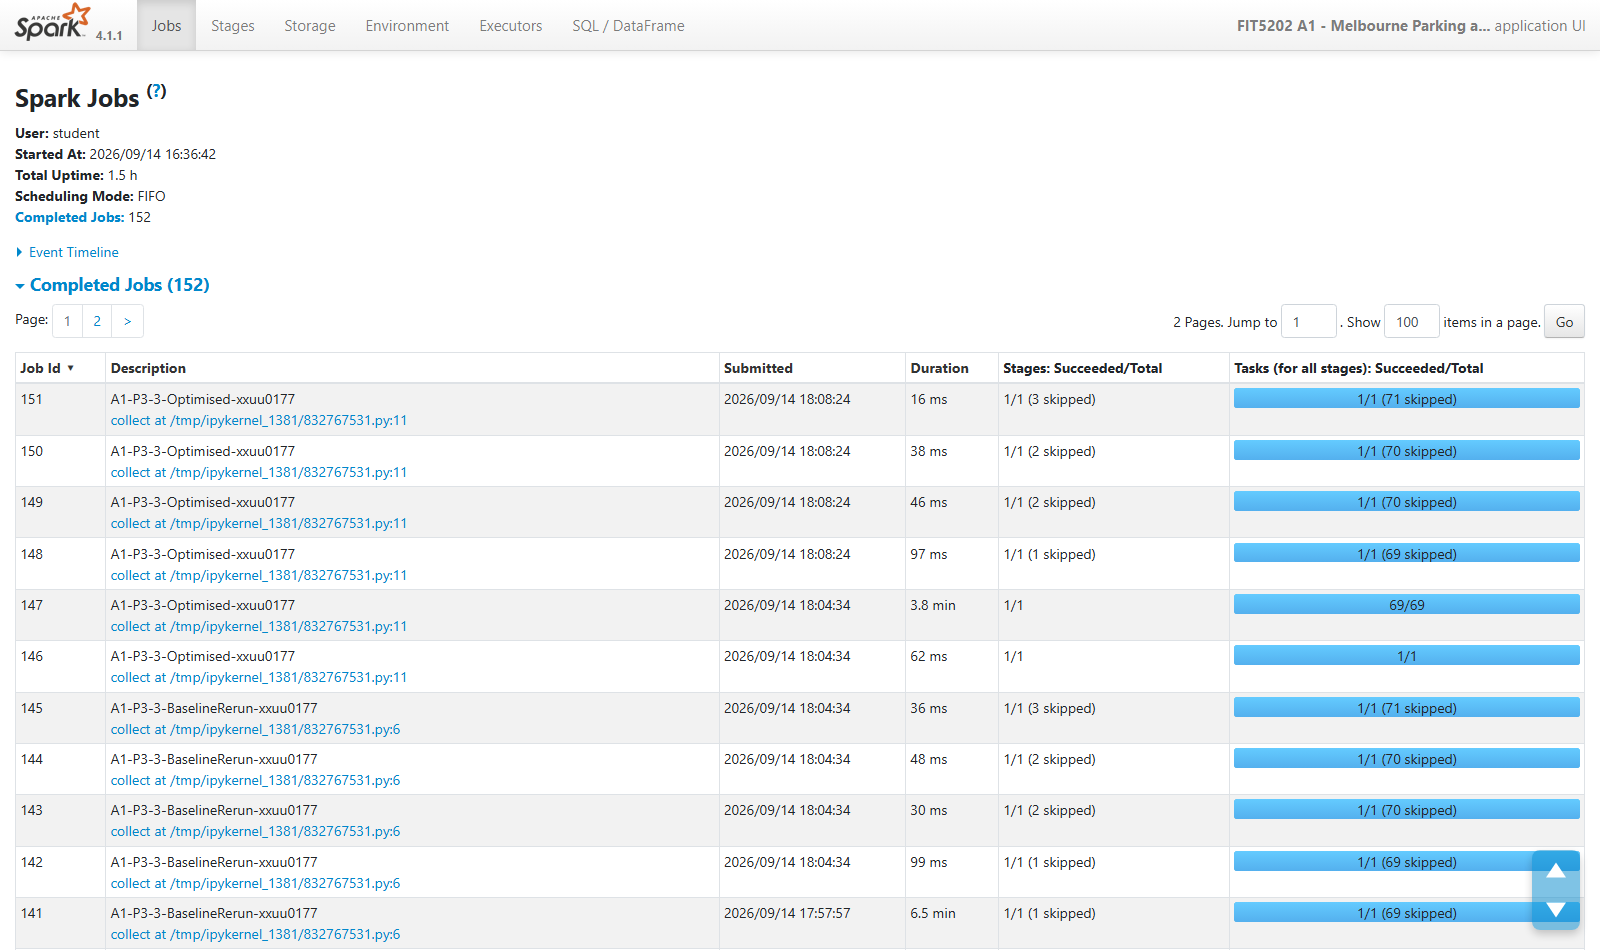

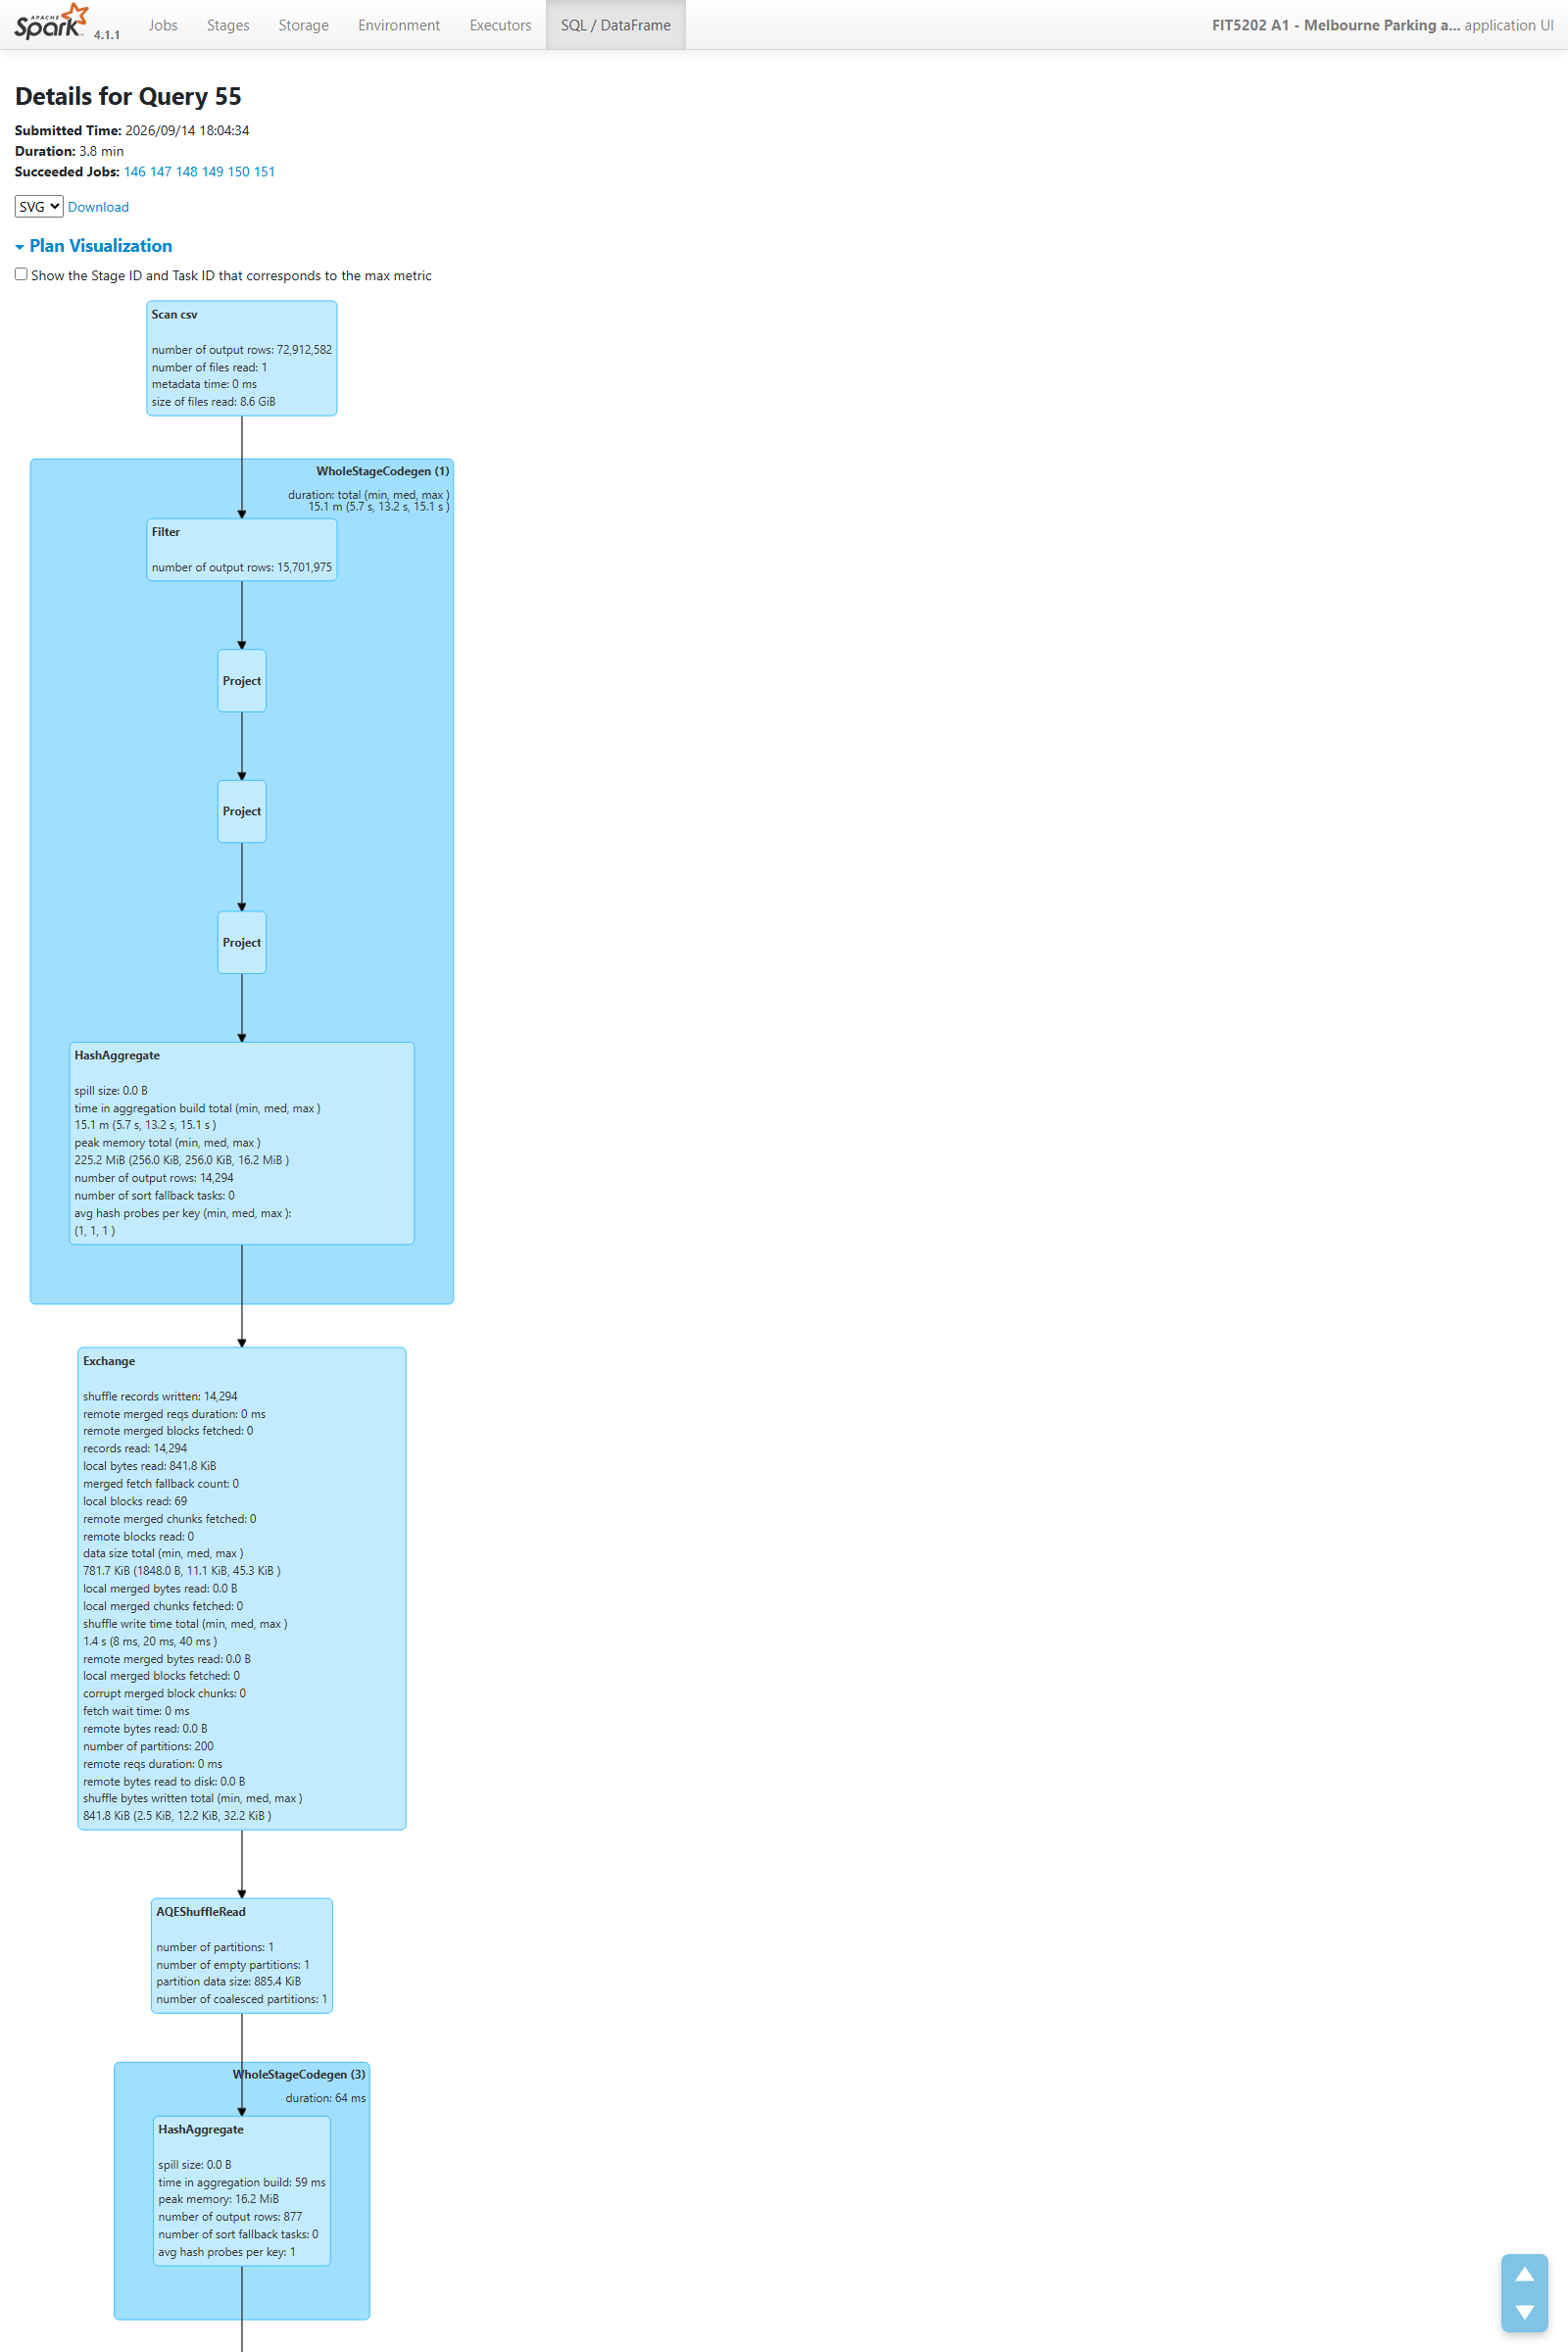

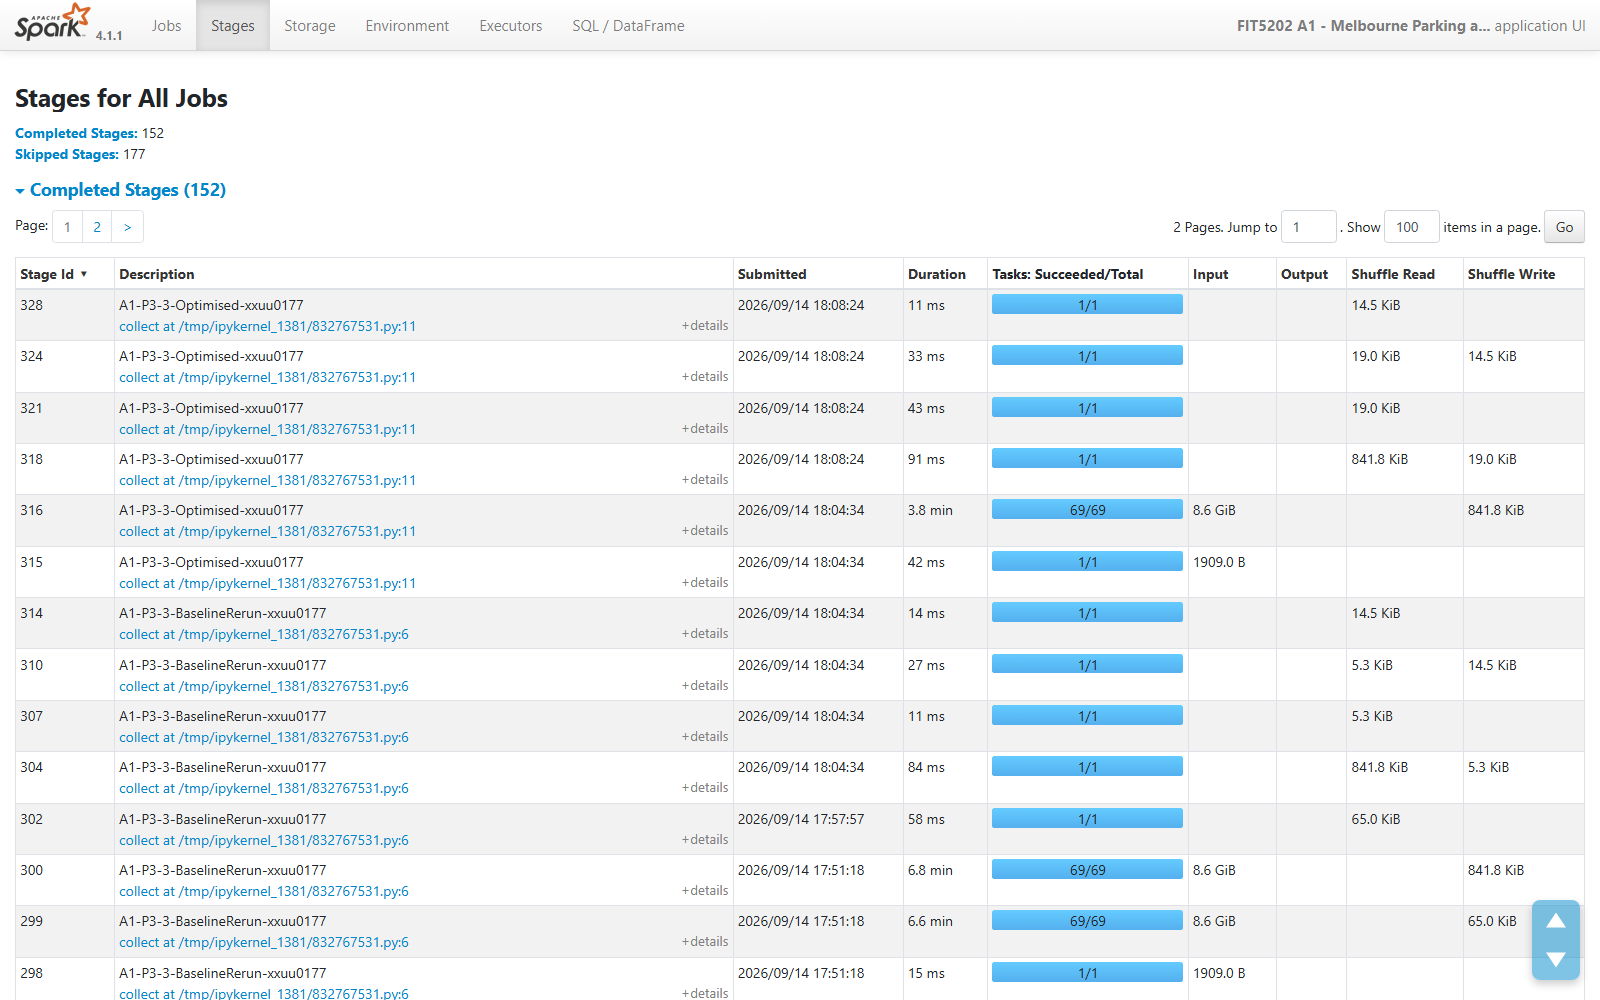

In [42]:
for f in ["p33_jobs.png","p33_sql_dag.png","p33_stages.png"]:
    display(Image(filename="screenshots/"+f))

**Evaluation of the optimisation (3.3)**

**Change and rationale.** The baseline computes the monthly benchmark with a second `groupBy("Month")` over the prepared rows, which forces a second scan of the 9.2 GB file. The benchmark is the monthly total of the same peak-hour sessions, so it can instead be derived from the per-area monthly aggregate as `SUM(ViolationCount) / SUM(ValidCount)` over a window partitioned by `Month`. Summing the per-area counts reproduces the monthly totals exactly, leaving the result unchanged while the file is read and parsed only once.

**Identical conditions.** Both queries ran consecutively in the same session, following a single `spark.catalog.clearCache()` call made before either query, each built as a new query object so that no shuffle files were reused, and both were materialised with `collect()`. The job descriptions `A1-P3-3-BaselineRerun-xxuu0177` and `A1-P3-3-Optimised-xxuu0177` were set immediately before each run, and AQE was enabled for both (the Spark 4 default). The two baseline runs differ by 4.4% (761.86 s and 795.74 s), a small variation relative to the gap to the optimised query.

| Run | Wall clock | Scan stages | Executor time in scans |
|---|---|---|---|
| Baseline (3.2) | 761.86 s | 2 x 69 tasks (282, 283) | 1,518 s + 1,514 s |
| Baseline (rerun) | 795.74 s | 2 x 69 tasks (299, 300) | 1,573 s + 1,596 s |
| **Optimised** | **230.11 s** | **1 x 69 tasks (316)** | **906 s** |

The optimisation yields a **3.46x speed-up** over the baseline rerun on the same data, cores and action. The plan shrinks from 38 to 28 operators and contains a single `Scan csv`, because the second scan branch and the `SortMergeJoin` that combined it are replaced by one additional `Window`. In the Spark UI, the single scan stage (316) takes 3.8 min, and each subsequent stage runs one task in at most 91 ms, since the window operates on 877 area-month rows.

**Equivalence.** Both queries return 120 rows, `exceptAll()` yields 0 in both directions, and the collected rows are identical and in the same order.

**Retention decision.** The optimisation should be retained. It removes a complete pass over the largest input without changing the output or adding memory pressure, and since the report runs regularly, the saving recurs on every execution. The speed-up exceeds the factor of two that would follow from removing one of two equal scans, because each baseline scan consumed 1,514 s to 1,596 s of executor time against 906 s for the single optimised scan. The physical plans do not explain this per-scan difference, so the decision rests on the removed scan and the measured wall-clock times rather than on the exact ratio.